<a href="https://colab.research.google.com/github/aishanee-sinha/Multi-Agent-Autonomous-Workforce-Assistant/blob/utkarsh_code%2Fmeeting_summarizer_demo/Meeting_Summarizer_WB_1_298B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install all required packages
# Fresh runtime assumed — installs everything needed end to end

import subprocess
import sys

print("Installing dependencies...")

packages = [
    "torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121",
    "transformers==4.41.2",
    "accelerate==0.32.0",
    "bitsandbytes==0.44.1",
    "peft==0.11.1",
    "trl==0.9.6",
    "datasets==2.19.0",
    "rouge-score",
    "bert-score",
    "nltk",
    "lxml",
    "dateparser",
    "icalendar",
    "python-dateutil",
    "pytz",
    "supabase",
    "python-dotenv",
    "scipy",
    "sentencepiece",
    "protobuf",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "tqdm",
    "gradio==4.44.0",
    "huggingface_hub",
]

def pip_install(spec):
    cmd = [sys.executable, "-m", "pip", "install", "--quiet"] + spec.split()
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"  WARNING: install failed for: {spec}")
        print(result.stderr[-300:])

for pkg in packages:
    pip_install(pkg)
    label = pkg.split()[0]
    print(f"  done: {label}")

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

print("")
print("All dependencies installed.")

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Installing dependencies...
  done: torch==2.3.1
  done: transformers==4.41.2
  done: accelerate==0.32.0
  done: bitsandbytes==0.44.1
  done: peft==0.11.1
  done: trl==0.9.6
  done: datasets==2.19.0
  done: rouge-score
  done: bert-score
  done: nltk
  done: lxml
  done: dateparser
  done: icalendar
  done: python-dateutil
  done: pytz
  done: supabase
  done: python-dotenv
  done: scipy
  done: sentencepiece
  done: protobuf
  done: scikit-learn
  done: pandas
  done: numpy
  done: matplotlib
  done: seaborn
  done: tqdm
  done: gradio==4.44.0
  done: huggingface_hub

All dependencies installed.
PyTorch version : 2.3.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4090
VRAM            : 25.8 GB


In [ ]:
# Cell 2: Imports and configuration
# All paths, model names, and Supabase settings live here.
# Edit PROTO_MODEL_PATH before running Section C if needed.

import os
import sys
import re
import gc
import json
import gzip
import time
import uuid
import hashlib
import warnings
import logging
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize

from dotenv import load_dotenv

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Load .env — service role key lives here
load_dotenv("./.env")

SUPABASE_URL          = os.environ.get("SUPABASE_URL", "")
SUPABASE_SERVICE_KEY  = os.environ.get("SUPABASE_SERVICE_ROLE_KEY", "")

if not SUPABASE_URL or not SUPABASE_SERVICE_KEY:
    print("WARNING: SUPABASE_URL or SUPABASE_SERVICE_ROLE_KEY not found in .env")
    print("  Make sure .env has both keys before running Section B or C.")
else:
    print("Supabase credentials loaded.")


@dataclass
class Config:
    # ------------------------------------------------------------------ paths
    AMI_DATA_DIR        : str = "./data"               # local AMI corpus root
    PHASE3_OUTPUT_DIR   : str = "./phase3_outputs"
    PHASE3_JSONL        : str = "./phase3_outputs/ami_parsed.jsonl"
    PHASE3_JSONL_GZ     : str = "./phase3_outputs/ami_parsed.jsonl.gz"

    # model checkpoints
    IMPROVED_MODEL_PATH : str = "./phase3_model/final_model"
    PROTO_MODEL_PATH    : str = "./proto_model/final_model"

    # ------------------------------------------------------------------ model
    BASE_MODEL          : str = "Qwen/Qwen2.5-7B-Instruct"
    USE_QLORA           : bool = True
    LOAD_IN_4BIT        : bool = True
    MAX_SEQ_LENGTH      : int = 4096
    MAX_NEW_TOKENS      : int = 1024

    # ------------------------------------------------------------------ LoRA
    LORA_R              : int = 32
    LORA_ALPHA          : int = 64
    LORA_DROPOUT        : float = 0.1
    LORA_TARGET_MODULES : List[str] = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ])

    # ------------------------------------------------------------------ training (continued fine-tune)
    NUM_EPOCHS              : int   = 3
    BATCH_SIZE              : int   = 2
    GRADIENT_ACCUMULATION   : int   = 4
    LEARNING_RATE           : float = 1e-4    # halved from Phase 2 (2e-4)
    RANDOM_SEED             : int   = 42

    # ------------------------------------------------------------------ chunking
    CHUNK_SIZE_TOKENS    : int = 1024
    CHUNK_OVERLAP_TOKENS : int = 64

    # ------------------------------------------------------------------ Supabase
    SUPABASE_BUCKET     : str = "msadi"
    MEETINGS_TABLE      : str = "meetings"
    RUNS_TABLE          : str = "runs"
    LATEST_RUNS_VIEW    : str = "latest_runs"

    # ------------------------------------------------------------------ ICS
    DEMO_MEETING_DATE   : str = "2026-02-10 10:00:00"

    # ------------------------------------------------------------------ HF Space
    HF_SPACE_REPO       : str = "utkarsh9630/msadi-workbook1-meeting"


cfg = Config()

# create output dirs
for d in [cfg.PHASE3_OUTPUT_DIR,
          f"{cfg.PHASE3_OUTPUT_DIR}/sample_summaries",
          f"{cfg.PHASE3_OUTPUT_DIR}/ics",
          f"{cfg.PHASE3_OUTPUT_DIR}/plots"]:
    os.makedirs(d, exist_ok=True)

print("Config ready.")
print(f"  Improved model  : {cfg.IMPROVED_MODEL_PATH}")
print(f"  Prototype model : {cfg.PROTO_MODEL_PATH}")
print(f"  AMI data dir    : {cfg.AMI_DATA_DIR}")
print(f"  Supabase bucket : {cfg.SUPABASE_BUCKET}")

/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Supabase credentials loaded.
Config ready.
  Improved model  : ./phase3_model/final_model
  Prototype model : ./proto_model/final_model
  AMI data dir    : ./data
  Supabase bucket : msadi


In [ ]:
# Fix: supabase requires websockets >= 13.0 which includes websockets.asyncio
# The conda base environment has an older websockets version.
# This cell pins compatible versions and restarts the import cleanly.

import subprocess
import sys

print("Fixing supabase + websockets version conflict...")

# uninstall conflicting versions first
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y",
     "supabase", "realtime", "websockets"],
    capture_output=True
)
print("  Uninstalled old versions.")

# install pinned compatible stack
packages = [
    "websockets>=13.0",
    "supabase==2.10.0",
    "realtime==2.0.2",
]
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  installed: {pkg}")
    else:
        print(f"  WARNING: failed to install {pkg}")
        print(result.stderr[-200:])

print("")
print("Verifying fix...")

# force reimport
import importlib
import sys

# remove cached broken modules
for mod in list(sys.modules.keys()):
    if any(mod.startswith(p) for p in ["supabase", "realtime", "websockets"]):
        del sys.modules[mod]

try:
    from supabase import create_client, Client
    print("supabase import: OK")
except Exception as e:
    print(f"supabase import still failing: {e}")
    print("Try: Runtime -> Restart Runtime, then run cells again from Cell 1")

try:
    import websockets
    print(f"websockets version: {websockets.__version__}")
except Exception as e:
    print(f"websockets import failed: {e}")

Fixing supabase + websockets version conflict...
  Uninstalled old versions.
  installed: websockets>=13.0
  installed: supabase==2.10.0
  installed: realtime==2.0.2

Verifying fix...
supabase import: OK
websockets version: 12.0


In [ ]:
# Cell 3: Supabase client and helper functions
# Uses service role key for all worker operations (read + write).

from supabase import create_client, Client

def get_supabase_client() -> Client:
    if not SUPABASE_URL or not SUPABASE_SERVICE_KEY:
        raise RuntimeError("Supabase credentials missing. Check .env file.")
    return create_client(SUPABASE_URL, SUPABASE_SERVICE_KEY)


def upload_file_to_storage(client: Client, bucket: str, storage_path: str, local_path: str):
    """
    Upload a local file to Supabase Storage.
    Overwrites if the path already exists (upsert=True).
    """
    with open(local_path, "rb") as f:
        data = f.read()
    # remove existing if present to avoid 409
    try:
        client.storage.from_(bucket).remove([storage_path])
    except Exception:
        pass
    res = client.storage.from_(bucket).upload(
        path=storage_path,
        file=data,
        file_options={"upsert": "true"},
    )
    return res


def upload_bytes_to_storage(client: Client, bucket: str, storage_path: str, data: bytes, content_type: str = "application/octet-stream"):
    """Upload raw bytes to Supabase Storage."""
    try:
        client.storage.from_(bucket).remove([storage_path])
    except Exception:
        pass
    res = client.storage.from_(bucket).upload(
        path=storage_path,
        file=data,
        file_options={"content-type": content_type, "upsert": "true"},
    )
    return res


def download_file_from_storage(client: Client, bucket: str, storage_path: str) -> bytes:
    """Download a file from Supabase Storage, returns raw bytes."""
    res = client.storage.from_(bucket).download(storage_path)
    return res


def insert_run_row(client: Client, row: dict):
    """Insert a row into the runs table."""
    res = client.table(cfg.RUNS_TABLE).insert(row).execute()
    return res


def insert_meeting_row(client: Client, row: dict):
    """Insert a row into the meetings table."""
    res = client.table(cfg.MEETINGS_TABLE).insert(row).execute()
    return res


def list_meetings(client: Client) -> list:
    """Fetch all rows from meetings table."""
    res = client.table(cfg.MEETINGS_TABLE).select("*").execute()
    return res.data or []


def meeting_exists(client: Client, meeting_id: str) -> bool:
    res = client.table(cfg.MEETINGS_TABLE).select("meeting_id").eq("meeting_id", meeting_id).execute()
    return len(res.data) > 0


# Quick connectivity test
try:
    sb = get_supabase_client()
    rows = sb.table(cfg.MEETINGS_TABLE).select("meeting_id").limit(1).execute()
    print("Supabase connection OK.")
    print(f"  Meetings table reachable. Rows returned in test: {len(rows.data)}")
except Exception as e:
    print(f"WARNING: Supabase connection test failed: {e}")
    print("  Check SUPABASE_URL and SUPABASE_SERVICE_ROLE_KEY in .env")

Supabase connection OK.
  Meetings table reachable. Rows returned in test: 1


In [ ]:
# Cell 4: AMI corpus parser
# Parses raw AMI XML annotation files into structured JSONL records.
# Output: phase3_outputs/ami_parsed.jsonl
# Requires the AMI corpus to be in cfg.AMI_DATA_DIR.
# Download AMI corpus from: https://groups.inf.ed.ac.uk/ami/download/

import glob
import logging
from lxml import etree
import dateparser
from nltk.tokenize import sent_tokenize

PARSER_VERSION = "1.2.0"
PARSER_LOG     = os.path.join(cfg.PHASE3_OUTPUT_DIR, "parser_warnings.log")

_p3_log = logging.getLogger("ami_parser")
_p3_log.setLevel(logging.WARNING)
if not _p3_log.handlers:
    _p3_log.addHandler(logging.FileHandler(PARSER_LOG, mode="w"))

_XML_PARSER  = etree.XMLParser(recover=True, remove_blank_text=False)
_FLOAT_RE    = re.compile(r"[-+]?(?:\d+\.\d+|\d+)(?:[eE][-+]?\d+)?")
_ISO_DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")


def _parse_float_any(x):
    if x is None:
        return None
    if isinstance(x, (int, float)):
        return float(x)
    m = _FLOAT_RE.search(str(x))
    return float(m.group(0)) if m else None


def _get_attr_any(elem, *names):
    for n in names:
        v = elem.get(n)
        if v is not None:
            return v
    for key, val in elem.attrib.items():
        k = key.lower()
        for n in names:
            if k.endswith(n.lower()):
                return val
    return None


def _get_time_pair(elem):
    st = _parse_float_any(_get_attr_any(elem, "starttime", "start", "startTime"))
    et = _parse_float_any(_get_attr_any(elem, "endtime", "end", "endTime"))
    return st, et


def _parse_words_file(xml_path: str) -> List[Dict]:
    """Parse a single AMI .words XML file into a list of word dicts."""
    try:
        tree = etree.parse(xml_path, _XML_PARSER)
    except Exception as e:
        _p3_log.warning(f"Cannot parse {xml_path}: {e}")
        return []
    root = tree.getroot()
    words = []
    for elem in root.iter():
        tag = elem.tag.split("}")[-1].lower() if "}" in elem.tag else elem.tag.lower()
        if tag == "w":
            text = (elem.text or "").strip()
            if not text:
                continue
            st, et = _get_time_pair(elem)
            words.append({"text": text, "start": st, "end": et})
    return words


def _words_to_utterances(words: List[Dict], speaker: str, gap_threshold: float = 1.5) -> List[Dict]:
    """Segment word list into utterances by time gaps."""
    if not words:
        return []
    utterances = []
    current_words = [words[0]]
    for w in words[1:]:
        prev_end = current_words[-1].get("end")
        curr_start = w.get("start")
        if prev_end is not None and curr_start is not None and (curr_start - prev_end) > gap_threshold:
            utt_text = " ".join(cw["text"] for cw in current_words)
            utt_start = current_words[0].get("start")
            utt_end   = current_words[-1].get("end")
            utterances.append({"speaker": speaker, "text": utt_text, "start": utt_start, "end": utt_end})
            current_words = [w]
        else:
            current_words.append(w)
    if current_words:
        utt_text  = " ".join(cw["text"] for cw in current_words)
        utt_start = current_words[0].get("start")
        utt_end   = current_words[-1].get("end")
        utterances.append({"speaker": speaker, "text": utt_text, "start": utt_start, "end": utt_end})
    return utterances


def _parse_abstractive_summary(xml_path: str) -> Dict:
    """Parse an AMI abstractive summary XML file."""
    out = {"abstract": "", "decisions": "", "problems": "", "actions": ""}
    if not os.path.isfile(xml_path):
        return out
    try:
        tree = etree.parse(xml_path, _XML_PARSER)
    except Exception:
        return out
    root = tree.getroot()
    section_map = {
        "abstract"  : "abstract",
        "decisions" : "decisions",
        "problems"  : "problems",
        "actions"   : "actions",
    }
    for elem in root.iter():
        tag = elem.tag.split("}")[-1].lower() if "}" in elem.tag else elem.tag.lower()
        if tag in section_map:
            texts = []
            for child in elem.iter():
                t = (child.text or "").strip()
                if t:
                    texts.append(t)
            if texts:
                out[section_map[tag]] = " ".join(texts)
    return out


def _parse_action_items(xml_path: str) -> List[Dict]:
    """Parse an AMI action items XML file."""
    items = []
    if not os.path.isfile(xml_path):
        return items
    try:
        tree = etree.parse(xml_path, _XML_PARSER)
    except Exception:
        return items
    root = tree.getroot()
    for elem in root.iter():
        tag = elem.tag.split("}")[-1].lower() if "}" in elem.tag else elem.tag.lower()
        if tag in ("actionitem", "action"):
            task     = ""
            owner    = "TBD"
            deadline = "TBD"
            disc_at  = None
            for child in elem.iter():
                ctag = child.tag.split("}")[-1].lower() if "}" in child.tag else child.tag.lower()
                t    = (child.text or "").strip()
                if ctag in ("description", "task", "text") and t:
                    task = t
                elif ctag in ("owner", "participant") and t:
                    owner = t
                elif ctag in ("deadline", "due") and t:
                    deadline = t
                elif ctag in ("time", "startsec") and t:
                    disc_at = _parse_float_any(t)
            if task:
                items.append({
                    "task"             : task,
                    "owner"            : owner,
                    "deadline"         : deadline,
                    "discussed_at_sec" : disc_at,
                })
    return items


def parse_ami_meeting(meeting_id: str, ami_dir: str) -> Optional[Dict]:
    """
    Parse all XML files for one AMI meeting into a structured dict.
    Returns None if no word files are found.
    """
    words_pattern = os.path.join(ami_dir, "words", f"{meeting_id}.*.words.xml")
    words_files   = sorted(glob.glob(words_pattern))

    if not words_files:
        # try flat layout
        words_pattern = os.path.join(ami_dir, f"{meeting_id}.*.words.xml")
        words_files   = sorted(glob.glob(words_pattern))

    if not words_files:
        _p3_log.warning(f"No word files for meeting: {meeting_id}")
        return None

    # collect all utterances from all speakers
    all_utterances = []
    speakers       = []
    for wf in words_files:
        # extract speaker from filename e.g. ES2002a.A.words.xml
        parts   = os.path.basename(wf).split(".")
        speaker = parts[1] if len(parts) >= 3 else "UNK"
        if speaker not in speakers:
            speakers.append(speaker)
        words = _parse_words_file(wf)
        utts  = _words_to_utterances(words, speaker)
        all_utterances.extend(utts)

    if not all_utterances:
        return None

    # sort utterances by start time
    all_utterances.sort(key=lambda u: (u["start"] is None, u["start"] or 0))

    # normalize time axis to start at 0
    starts = [u["start"] for u in all_utterances if u["start"] is not None]
    ends   = [u["end"]   for u in all_utterances if u["end"]   is not None]
    meeting_start_raw = min(starts) if starts else 0.0
    meeting_end_raw   = max(ends)   if ends   else 0.0
    duration_sec      = meeting_end_raw - meeting_start_raw if (starts and ends) else None

    for u in all_utterances:
        if u["start"] is not None:
            u["start"] = round(u["start"] - meeting_start_raw, 3)
        if u["end"] is not None:
            u["end"]   = round(u["end"]   - meeting_start_raw, 3)

    # build transcript text
    transcript = "\n".join(
        f"[{u['speaker']}] {u['text']}" for u in all_utterances
    )

    # parse summaries
    summ_path = os.path.join(ami_dir, "abstractive", f"{meeting_id}.abssumm.xml")
    # try alternate layout
    if not os.path.isfile(summ_path):
        summ_path = os.path.join(ami_dir, f"{meeting_id}.abssumm.xml")
    summary = _parse_abstractive_summary(summ_path)

    # parse action items
    act_path = os.path.join(ami_dir, "extractive", f"{meeting_id}.extsumm.xml")
    if not os.path.isfile(act_path):
        act_path = os.path.join(ami_dir, f"{meeting_id}.extsumm.xml")
    action_items = _parse_action_items(act_path)

    # normalize discussed_at_sec so it is within duration
    for a in action_items:
        d = a.get("discussed_at_sec")
        if d is not None:
            a["discussed_at_sec"] = round(d - meeting_start_raw, 3)
            if duration_sec and a["discussed_at_sec"] > duration_sec:
                a["discussed_at_sec"] = duration_sec

    utt_with_ts = sum(1 for u in all_utterances if u["start"] is not None)

    record = {
        "meeting_id"         : meeting_id,
        "speakers"           : speakers,
        "utterances"         : all_utterances,
        "transcript"         : transcript,
        "summary_abstract"   : summary["abstract"],
        "summary_decisions"  : summary["decisions"],
        "summary_problems"   : summary["problems"],
        "summary_actions"    : summary["actions"],
        "action_items"       : action_items,
        "metadata"           : {
            "duration_sec"            : round(duration_sec, 3) if duration_sec else None,
            "num_utterances"          : len(all_utterances),
            "num_utterances_with_ts"  : utt_with_ts,
            "num_speakers"            : len(speakers),
            "parser_version"          : PARSER_VERSION,
            "parse_warnings"          : [],
        },
    }
    return record


def run_ami_parser(ami_dir: str, output_jsonl: str) -> dict:
    """
    Parse all meetings in ami_dir and write to output_jsonl.
    Discovers meeting IDs from word file names.
    """
    # discover meeting IDs
    pattern1 = os.path.join(ami_dir, "words", "*.words.xml")
    pattern2 = os.path.join(ami_dir, "*.words.xml")
    word_files = sorted(glob.glob(pattern1)) + sorted(glob.glob(pattern2))

    meeting_ids = sorted({
        os.path.basename(f).split(".")[0]
        for f in word_files
    })

    if not meeting_ids:
        print(f"ERROR: No AMI word files found in {ami_dir}")
        print("  Expected pattern: <meeting_id>.<speaker>.words.xml")
        print("  Download AMI corpus from https://groups.inf.ed.ac.uk/ami/download/")
        return {}

    print(f"Found {len(meeting_ids)} unique meeting IDs in {ami_dir}")

    stats = {"total": len(meeting_ids), "parsed": 0, "failed": 0}
    os.makedirs(os.path.dirname(output_jsonl), exist_ok=True)

    with open(output_jsonl, "w", encoding="utf-8") as out_f:
        for mid in tqdm(meeting_ids, desc="Parsing AMI meetings"):
            record = parse_ami_meeting(mid, ami_dir)
            if record is None:
                stats["failed"] += 1
                continue
            out_f.write(json.dumps(record, ensure_ascii=False) + "\n")
            stats["parsed"] += 1

    print(f"Parser done. Parsed: {stats['parsed']}, Failed: {stats['failed']}")
    print(f"Output: {output_jsonl}")
    return stats


# run the parser
parser_stats = run_ami_parser(cfg.AMI_DATA_DIR, cfg.PHASE3_JSONL)

Found 171 unique meeting IDs in ./data


Parsing AMI meetings: 100%|██████████| 171/171 [00:11<00:00, 15.09it/s]

Parser done. Parsed: 171, Failed: 0
Output: ./phase3_outputs/ami_parsed.jsonl


In [ ]:
# Cell 5: Compress JSONL and upload dataset to Supabase Storage
# Also inserts meeting rows into the meetings table.

print("Compressing JSONL...")

with open(cfg.PHASE3_JSONL, "rb") as f_in:
    raw = f_in.read()
with gzip.open(cfg.PHASE3_JSONL_GZ, "wb") as f_out:
    f_out.write(raw)

gz_size_mb = os.path.getsize(cfg.PHASE3_JSONL_GZ) / 1e6
print(f"Compressed: {gz_size_mb:.2f} MB  ->  {cfg.PHASE3_JSONL_GZ}")

sb = get_supabase_client()

# upload compressed dataset
print("Uploading dataset to Supabase Storage...")
upload_file_to_storage(
    client       = sb,
    bucket       = cfg.SUPABASE_BUCKET,
    storage_path = "datasets/ami_parsed.jsonl.gz",
    local_path   = cfg.PHASE3_JSONL_GZ,
)
print("  datasets/ami_parsed.jsonl.gz uploaded.")

# load records and insert meeting rows
print("Inserting meeting rows into Supabase...")
records = []
with open(cfg.PHASE3_JSONL, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

inserted   = 0
skipped    = 0
failed_ids = []

for rec in tqdm(records, desc="Inserting meetings"):
    mid = rec["meeting_id"]
    if meeting_exists(sb, mid):
        skipped += 1
        continue
    transcript_storage_path = f"meetings/{mid}/transcript.txt"
    # upload transcript text
    try:
        upload_bytes_to_storage(
            client       = sb,
            bucket       = cfg.SUPABASE_BUCKET,
            storage_path = transcript_storage_path,
            data         = rec["transcript"].encode("utf-8"),
            content_type = "text/plain",
        )
    except Exception as e:
        print(f"  WARNING: transcript upload failed for {mid}: {e}")

    duration = rec.get("metadata", {}).get("duration_sec")
    row = {
        "meeting_id"      : mid,
        "title"           : mid,
        "transcript_path" : transcript_storage_path,
        "duration_sec"    : duration,
    }
    try:
        insert_meeting_row(sb, row)
        inserted += 1
    except Exception as e:
        print(f"  WARNING: DB insert failed for {mid}: {e}")
        failed_ids.append(mid)

print(f"Meeting upload done.")
print(f"  Inserted : {inserted}")
print(f"  Skipped  : {skipped} (already in DB)")
print(f"  Failed   : {len(failed_ids)}")
if failed_ids:
    print(f"  Failed IDs: {failed_ids[:10]}")

Compressing JSONL...
Compressed: 4.18 MB  ->  ./phase3_outputs/ami_parsed.jsonl.gz
Uploading dataset to Supabase Storage...
  datasets/ami_parsed.jsonl.gz uploaded.
Inserting meeting rows into Supabase...


Inserting meetings: 100%|██████████| 171/171 [00:19<00:00,  8.79it/s]

Meeting upload done.
  Inserted : 0
  Skipped  : 171 (already in DB)
  Failed   : 0


In [ ]:
# Cell 6: Evaluation functions
# G-Eval heuristic suite (same as prototype/Phase 2 so metrics are comparable).
# Also includes ROUGE-L and BERTScore wrappers.

from sklearn.metrics import precision_recall_fscore_support

# --- tokenizer helpers ---

def _normalize_score(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, x))

def _safe_ratio(n, d):
    return 0.0 if d <= 0 else n / d

def _tokenize_text(s: str) -> List[str]:
    return re.findall(r"\w+", s.lower())


# --- G-Eval dimensions ---

def geval_coherence(summary: str) -> float:
    sents   = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len = sum(len(_tokenize_text(s)) for s in sents) / len(sents)
    penalty_frag = 1.0 if avg_len >= 8 else avg_len / 8.0
    overlaps = []
    for i in range(len(sents) - 1):
        a = set(_tokenize_text(sents[i]))
        b = set(_tokenize_text(sents[i + 1]))
        overlaps.append(_safe_ratio(len(a & b), len(a | b)))
    local = np.mean(overlaps) if overlaps else 0.0
    return _normalize_score(0.6 * penalty_frag + 0.4 * local)


def geval_consistency(summary: str, source: str) -> float:
    src    = set(_tokenize_text(source))
    summ   = _tokenize_text(summary)
    nums   = [t for t in summ if re.fullmatch(r"\d+", t)]
    proper = [p.lower() for p in re.findall(r"\b[A-Z][a-zA-Z]+\b", summary)]
    hallu  = sum(1 for t in nums + proper if t not in src)
    rate   = 1.0 - _safe_ratio(hallu, max(1, len(nums) + len(proper)))
    return _normalize_score(rate)


def geval_fluency(summary: str) -> float:
    toks  = _tokenize_text(summary)
    sents = [s for s in sent_tokenize(summary) if s.strip()]
    if not sents:
        return 0.0
    avg_len  = len(toks) / len(sents)
    rep_pen  = 1.0 - _safe_ratio(len(toks) - len(set(toks)), max(1, len(toks)))
    len_sc   = 1.0 - min(1.0, abs(avg_len - 20) / 20)
    return _normalize_score(0.5 * rep_pen + 0.5 * len_sc)


def geval_relevance(summary: str, source: str) -> float:
    src_toks  = set(_tokenize_text(source))
    summ_toks = _tokenize_text(summary)
    if not summ_toks:
        return 0.0
    cov = _safe_ratio(sum(1 for t in summ_toks if t in src_toks), len(summ_toks))
    src_freq: Dict[str, int] = {}
    for t in _tokenize_text(source):
        src_freq[t] = src_freq.get(t, 0) + 1
    top_words  = set(w for w, _ in sorted(src_freq.items(), key=lambda x: x[1], reverse=True)[:20])
    top_cov    = _safe_ratio(sum(1 for t in summ_toks if t in top_words), len(summ_toks))
    return _normalize_score(0.6 * cov + 0.4 * top_cov)


def geval_action_quality(summary: str) -> float:
    # section presence check (covers both prototype and Phase-3 formats)
    header_found = bool(re.search(r"(?i)actions?(?:\s+items?)?:", summary))
    if not header_found:
        return 0.0
    # extract action lines
    action_lines = re.findall(
        r"(?i)(?:\[([^\]]+)\]|([A-Z][a-z]+(?:\s[A-Z][a-z]+)*))\s*[-—]\s*(.+?)(?:\s*[-—]\s*(?:due|by|deadline):\s*([^\n]+))?$",
        summary, re.MULTILINE
    )
    if not action_lines:
        return 0.3  # header present but no structured lines
    with_owner    = sum(1 for a in action_lines if (a[0] or a[1]).strip())
    with_deadline = sum(1 for a in action_lines if a[3].strip())
    owner_rate    = _safe_ratio(with_owner,    len(action_lines))
    deadline_rate = _safe_ratio(with_deadline, len(action_lines))
    count_score   = _normalize_score(len(action_lines) / 5.0)
    return _normalize_score(0.4 * owner_rate + 0.3 * deadline_rate + 0.3 * count_score)


def geval_comprehensive(summary: str, source: str) -> Dict:
    coherence      = geval_coherence(summary)
    consistency    = geval_consistency(summary, source)
    fluency        = geval_fluency(summary)
    relevance      = geval_relevance(summary, source)
    action_quality = geval_action_quality(summary)
    geval_overall  = _normalize_score(
        0.25 * coherence + 0.25 * consistency +
        0.20 * fluency   + 0.20 * relevance   +
        0.10 * action_quality
    )
    production_score = _normalize_score(
        0.35 * geval_overall +
        0.25 * action_quality +
        0.20 * consistency +
        0.20 * relevance
    )
    return {
        "coherence"       : coherence,
        "consistency"     : consistency,
        "fluency"         : fluency,
        "relevance"       : relevance,
        "action_quality"  : action_quality,
        "geval_overall"   : geval_overall,
        "production_score": production_score,
    }


# --- ROUGE-L ---

def compute_rouge_l(hypothesis: str, reference: str) -> float:
    try:
        from rouge_score import rouge_scorer
        scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
        score  = scorer.score(reference, hypothesis)
        return score["rougeL"].fmeasure
    except Exception:
        return 0.0


# --- BERTScore ---

def compute_bert_score(hypotheses: List[str], references: List[str]) -> List[float]:
    try:
        from bert_score import score as bscore
        P, R, F1 = bscore(hypotheses, references, lang="en", verbose=False)
        return F1.tolist()
    except Exception as e:
        print(f"  WARNING: BERTScore failed: {e}")
        return [0.0] * len(hypotheses)


# --- Action item F1 ---

def compute_action_f1(pred_actions: List[Dict], gold_actions: List[Dict]) -> Dict:
    """
    Compare predicted vs gold action items by task text overlap.
    Returns precision, recall, F1.
    """
    def _task_tokens(a):
        return set(_tokenize_text(a.get("task", "")))

    pred_tasks = [_task_tokens(a) for a in pred_actions]
    gold_tasks = [_task_tokens(a) for a in gold_actions]

    if not pred_tasks or not gold_tasks:
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

    matched_pred = set()
    matched_gold = set()
    for i, pt in enumerate(pred_tasks):
        for j, gt in enumerate(gold_tasks):
            if pt and gt and _safe_ratio(len(pt & gt), len(pt | gt)) >= 0.3:
                matched_pred.add(i)
                matched_gold.add(j)

    prec   = _safe_ratio(len(matched_pred), len(pred_tasks))
    recall = _safe_ratio(len(matched_gold), len(gold_tasks))
    f1     = _safe_ratio(2 * prec * recall, prec + recall)
    return {"precision": prec, "recall": recall, "f1": f1}


print("Evaluation functions defined.")
print("  G-Eval: coherence, consistency, fluency, relevance, action_quality, geval_overall, production_score")
print("  ROUGE-L, BERTScore, Action F1")

Evaluation functions defined.
  G-Eval: coherence, consistency, fluency, relevance, action_quality, geval_overall, production_score
  ROUGE-L, BERTScore, Action F1


In [ ]:
# Cell 7: Output cleaning and prompt builders for both model types
# Prototype uses Phase-1/2 style prompt.
# Improved model uses Phase-3 prompt with ACTIONS_JSON.

_STRUCTURED_HEADERS = ["ABSTRACT:", "DECISIONS:", "ACTIONS:", "PROBLEMS:", "ACTION:"]
_HEADER_RE          = re.compile(r"(?:ABSTRACT|DECISIONS?|ACTIONS?|PROBLEMS?):", re.IGNORECASE)
_ACTIONS_JSON_RE    = re.compile(r"ACTIONS_JSON:\s*(\[.*?\])", re.DOTALL | re.IGNORECASE)


def clean_structured_summary(raw_text: str) -> str:
    """
    Slice the raw model output to start at the first recognized section header.
    Strips Qwen chat tokens, normalizes whitespace.
    """
    text = re.sub(r"<\|im_start\|>\w*", "", raw_text)
    text = re.sub(r"<\|im_end\|>", "", text)
    earliest = len(text)
    for h in _STRUCTURED_HEADERS:
        idx = text.upper().find(h.upper())
        if idx != -1 and idx < earliest:
            earliest = idx
    if earliest < len(text):
        text = text[earliest:]
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# ---- Prototype (last sem) prompt style ----

PROTO_SYSTEM_PROMPT = (
    "You are an expert meeting summarizer. Given a meeting transcript, "
    "generate a comprehensive meeting summary with the following sections:\n\n"
    "1. ABSTRACT: A brief overview of the meeting\n"
    "2. DECISIONS: Key decisions made during the meeting\n"
    "3. ACTIONS: Action items with owners and deadlines\n"
    "4. PROBLEMS: Issues or challenges discussed\n\n"
    "Format action items as:\n"
    "[Owner] - Task description - Due: Deadline\n\n"
    "Be concise, factual, and preserve important details."
)


def create_proto_prompt(transcript: str) -> str:
    return (
        f"<|im_start|>system\n"
        f"You are a helpful assistant specialized in meeting summarization.<|im_end|>\n"
        f"<|im_start|>user\n"
        f"{PROTO_SYSTEM_PROMPT}\n\n"
        f"TRANSCRIPT:\n{transcript}\n\n"
        f"Generate the meeting summary:<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


# ---- Improved (Phase-3) prompt style ----

PHASE3_SYSTEM_PROMPT = (
    "You are a meeting minutes assistant. "
    "Produce structured minutes and an ACTIONS_JSON array."
)

PHASE3_USER_INSTRUCTION = (
    "Given the meeting transcript, write:\n"
    "1) ABSTRACT, DECISIONS, PROBLEMS, ACTIONS sections (concise)\n"
    "2) ACTIONS_JSON with owner/task/deadline/discussed_at_sec\n"
    "Rules:\n"
    "- Do not invent facts not in the transcript.\n"
    "- If deadline/owner is missing, set 'TBD'.\n"
    "- ACTIONS_JSON must be valid JSON."
)


def create_p3_prompt(transcript: str) -> str:
    return (
        f"<|im_start|>system\n{PHASE3_SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n"
        f"{PHASE3_USER_INSTRUCTION}\n\n"
        f"TRANSCRIPT:\n{transcript}\n"
        f"<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


def parse_actions_json(cleaned: str) -> Tuple[List[Dict], bool, str]:
    """
    Extract and parse ACTIONS_JSON block from model output.
    Returns (actions_list, is_valid, error_message).
    """
    m = _ACTIONS_JSON_RE.search(cleaned)
    if not m:
        return [], False, "ACTIONS_JSON block not found"
    candidate = m.group(1).strip()
    try:
        return json.loads(candidate), True, ""
    except json.JSONDecodeError as e:
        # attempt repair: truncate at last ]
        try:
            fixed = candidate[:candidate.rfind("]") + 1]
            return json.loads(fixed), True, f"repaired: {e}"
        except Exception:
            return [], False, str(e)


print("Prompt builders and output cleaners defined.")
print("  create_proto_prompt()  : prototype style")
print("  create_p3_prompt()     : Phase-3 style with ACTIONS_JSON")

Prompt builders and output cleaners defined.
  create_proto_prompt()  : prototype style
  create_p3_prompt()     : Phase-3 style with ACTIONS_JSON


In [ ]:
# Cell 8: Model loaders — handles both model architectures
# Prototype  : google/flan-t5-large (Seq2Seq, LoRA, beam search)
# Improved   : Qwen2.5-7B-Instruct (CausalLM, QLoRA, sampling)

import time
from torch.utils.data import Dataset as TorchDataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

# -----------------------------------------------------------------------
# Prototype model helpers (flan-t5-large, Seq2Seq)
# -----------------------------------------------------------------------

PROTO_BASE_MODEL   = "google/flan-t5-large"
PROTO_SAVE_DIR     = "./proto_model/final_model"
PROTO_LORA_MODULES = ["q", "v", "k", "o", "wi", "wo"]

PROTO_COT_PROMPT = (
    "You are an expert meeting summarizer. Follow these steps:\n"
    "Step 1: Identify the main topics discussed.\n"
    "Step 2: Identify any decisions made.\n"
    "Step 3: Identify action items and who is responsible.\n"
    "Step 4: Write a structured summary.\n\n"
    "Generate a meeting summary with sections:\n"
    "ABSTRACT: [brief overview]\n"
    "DECISIONS: [key decisions]\n"
    "ACTIONS: [action items as: [Owner] - Task - Due: Deadline]\n"
    "PROBLEMS: [issues discussed]\n\n"
    "TRANSCRIPT:\n{transcript}\n\nSUMMARY:"
)


def build_proto_prompt(transcript: str) -> str:
    return PROTO_COT_PROMPT.format(transcript=transcript[:1800])


def train_proto_model(train_data: List[Dict], val_data: List[Dict]) -> Tuple:
    """
    Train flan-t5-large on AMI data with LoRA.
    train_data / val_data are lists of dicts with 'transcript' and 'summary' keys.
    Returns (model, tokenizer) ready for inference.
    """
    # local imports inside function so they are always available
    # regardless of cell execution order
    from torch.utils.data import Dataset as TorchDataset
    from transformers import (
        DataCollatorForSeq2Seq,
        TrainingArguments,
        Trainer,
    )

    print("Training prototype model: google/flan-t5-large + LoRA")
    print(f"  Train samples : {len(train_data)}")
    print(f"  Val samples   : {len(val_data)}")

    tokenizer = AutoTokenizer.from_pretrained(PROTO_BASE_MODEL, use_fast=True)

    base = AutoModelForSeq2SeqLM.from_pretrained(
        PROTO_BASE_MODEL,
        torch_dtype = torch.bfloat16,
        device_map  = "auto",
    )

    lora_cfg = LoraConfig(
        r              = 32,
        lora_alpha     = 64,
        target_modules = PROTO_LORA_MODULES,
        lora_dropout   = 0.1,
        bias           = "none",
        task_type      = TaskType.SEQ_2_SEQ_LM,
    )
    model = get_peft_model(base, lora_cfg)
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    MAX_SRC = 1024
    MAX_TGT = 512

    class ProtoDataset(TorchDataset):
        def __init__(self, records):
            self.items = []
            for rec in records:
                prompt  = build_proto_prompt(rec["transcript"])
                enc_in  = tokenizer(
                    prompt,
                    max_length = MAX_SRC,
                    truncation = True,
                    padding    = False,
                )
                enc_tgt = tokenizer(
                    rec["summary"],
                    max_length = MAX_TGT,
                    truncation = True,
                    padding    = False,
                )
                self.items.append({
                    "input_ids"      : enc_in["input_ids"],
                    "attention_mask" : enc_in["attention_mask"],
                    "labels"         : enc_tgt["input_ids"],
                })

        def __len__(self):
            return len(self.items)

        def __getitem__(self, i):
            return self.items[i]

    train_ds = ProtoDataset(train_data)
    val_ds   = ProtoDataset(val_data)

    print(f"  Tokenized train: {len(train_ds)} samples")
    print(f"  Tokenized val  : {len(val_ds)} samples")

    collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

    training_args = TrainingArguments(
        output_dir                  = PROTO_SAVE_DIR,
        num_train_epochs            = 8,
        per_device_train_batch_size = 4,
        per_device_eval_batch_size  = 4,
        gradient_accumulation_steps = 4,
        learning_rate               = 5e-5,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        lr_scheduler_type           = "linear",
        logging_steps               = 25,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        save_total_limit            = 2,
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        bf16                        = True,
        tf32                        = True,
        optim                       = "adamw_torch_fused",
        gradient_checkpointing      = True,
        dataloader_num_workers      = 0,
        report_to                   = "none",
        seed                        = 42,
    )

    trainer = Trainer(
        model         = model,
        args          = training_args,
        train_dataset = train_ds,
        eval_dataset  = val_ds,
        data_collator = collator,
    )

    print("Starting prototype training...")
    t0 = time.time()
    trainer.train()
    elapsed = (time.time() - t0) / 60
    print(f"Training done in {elapsed:.1f} min.")

    os.makedirs(PROTO_SAVE_DIR, exist_ok=True)
    model.save_pretrained(PROTO_SAVE_DIR)
    tokenizer.save_pretrained(PROTO_SAVE_DIR)
    print(f"Prototype model saved: {PROTO_SAVE_DIR}")
    return model, tokenizer


def load_proto_model() -> Tuple:
    """Load trained flan-t5-large + LoRA adapter for inference."""
    print(f"Loading prototype model from {PROTO_SAVE_DIR}...")
    tokenizer = AutoTokenizer.from_pretrained(PROTO_SAVE_DIR, use_fast=True)
    base = AutoModelForSeq2SeqLM.from_pretrained(
        PROTO_BASE_MODEL,
        torch_dtype = torch.bfloat16,
        device_map  = "auto",
    )
    model = PeftModel.from_pretrained(base, PROTO_SAVE_DIR)
    model.eval()
    print("Prototype model loaded.")
    return model, tokenizer


def generate_proto_summary(model, tokenizer, transcript: str) -> str:
    """Generate summary using prototype model (beam search, Seq2Seq style)."""
    prompt = build_proto_prompt(transcript)
    inputs = tokenizer(
        prompt,
        max_length     = 1024,
        truncation     = True,
        return_tensors = "pt",
    ).to(next(model.parameters()).device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length           = 512,
            min_length           = 80,
            num_beams            = 4,
            length_penalty       = 1.0,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
        )
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


# -----------------------------------------------------------------------
# Improved model helpers (Qwen2.5-7B, CausalLM, QLoRA)
# -----------------------------------------------------------------------

def load_improved_model() -> Tuple:
    """Load Qwen2.5-7B + Phase-3 LoRA adapter for inference."""
    print(f"Loading improved model from {cfg.IMPROVED_MODEL_PATH}...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,
        bnb_4bit_use_double_quant = True,
        bnb_4bit_quant_type       = "nf4",
        bnb_4bit_compute_dtype    = torch.bfloat16,
    )
    tokenizer = AutoTokenizer.from_pretrained(cfg.BASE_MODEL, trust_remote_code=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    base = AutoModelForCausalLM.from_pretrained(
        cfg.BASE_MODEL,
        quantization_config = bnb_config,
        device_map          = "auto",
        trust_remote_code   = True,
    )
    base.config.use_cache = False
    model = PeftModel.from_pretrained(base, cfg.IMPROVED_MODEL_PATH)
    model.eval()
    print("Improved model loaded.")
    return model, tokenizer


def generate_improved_summary(model, tokenizer, transcript: str) -> str:
    """Generate summary using improved model (sampling, CausalLM style)."""
    prompt = create_p3_prompt(transcript[:3000])
    inputs = tokenizer(
        prompt,
        return_tensors = "pt",
        max_length     = cfg.MAX_SEQ_LENGTH,
        truncation     = True,
        padding        = False,
    ).to(next(model.parameters()).device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens     = cfg.MAX_NEW_TOKENS,
            min_new_tokens     = 50,
            do_sample          = True,
            temperature        = 0.3,
            top_p              = 0.9,
            repetition_penalty = 1.1,
            use_cache          = True,
            pad_token_id       = tokenizer.eos_token_id,
        )
    prompt_len = inputs["input_ids"].shape[1]
    new_ids    = output_ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


print("Model loaders defined for both architectures.")
print("  Prototype  : flan-t5-large + LoRA (Seq2Seq, beam search)")
print("  Improved   : Qwen2.5-7B-Instruct + QLoRA (CausalLM, sampling)")

Model loaders defined for both architectures.
  Prototype  : flan-t5-large + LoRA (Seq2Seq, beam search)
  Improved   : Qwen2.5-7B-Instruct + QLoRA (CausalLM, sampling)


In [ ]:
# Cell 9: Load ami_parsed.jsonl for both models
# Both prototype (T5) and improved (Qwen) train and evaluate on the
# same locally parsed AMI data. This ensures a fair comparison.
# No HuggingFace Hub connection required.

# -----------------------------------------------------------------------
# load_ami_jsonl: deterministic hash-based split, no meeting_id leakage
# -----------------------------------------------------------------------
def load_ami_jsonl(
    path       : str,
    train_frac : float = 0.80,
    val_frac   : float = 0.10,
    seed       : int   = 42,
) -> Tuple[List[Dict], List[Dict], List[Dict]]:
    """
    Load ami_parsed.jsonl and split into train / val / test.
    Split is deterministic by hashing meeting_id so there is no leakage
    and results are reproducible without shuffling the file.
    Returns three plain lists of meeting dicts.
    """
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"ami_parsed.jsonl not found: {path}\n"
            "Run Cell 4 (AMI parser) first."
        )

    records: List[Dict] = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))

    print(f"  Loaded {len(records)} meeting records from {path}")

    def _bucket(mid: str) -> str:
        h = int(hashlib.sha256((mid + str(seed)).encode()).hexdigest(), 16) % 100
        if h < int(train_frac * 100):
            return "train"
        elif h < int((train_frac + val_frac) * 100):
            return "val"
        return "test"

    splits: Dict[str, List[Dict]] = {"train": [], "val": [], "test": []}
    for rec in records:
        splits[_bucket(rec["meeting_id"])].append(rec)

    # sanity: no leakage between splits
    train_ids = {r["meeting_id"] for r in splits["train"]}
    val_ids   = {r["meeting_id"] for r in splits["val"]}
    test_ids  = {r["meeting_id"] for r in splits["test"]}
    assert not (train_ids & val_ids),  "Data leak: train/val overlap"
    assert not (train_ids & test_ids), "Data leak: train/test overlap"
    assert not (val_ids   & test_ids), "Data leak: val/test overlap"

    print(f"  Train : {len(splits['train'])} meetings")
    print(f"  Val   : {len(splits['val'])} meetings")
    print(f"  Test  : {len(splits['test'])} meetings")

    return splits["train"], splits["val"], splits["test"]


# -----------------------------------------------------------------------
# Run the loader
# -----------------------------------------------------------------------
print("Loading local ami_parsed.jsonl...")
ami_train, ami_val, ami_test = load_ami_jsonl(cfg.PHASE3_JSONL)

# -----------------------------------------------------------------------
# Shared lookups used during evaluation (same for both models)
# -----------------------------------------------------------------------
test_transcript_map = {
    r["meeting_id"]: r.get("transcript", "")
    for r in ami_test
}

test_gold_actions = {
    r["meeting_id"]: r.get("action_items", [])
    for r in ami_test
}

test_references = {
    r["meeting_id"]: "\n".join(filter(None, [
        r.get("summary_abstract",  ""),
        r.get("summary_decisions", ""),
        r.get("summary_actions",   ""),
        r.get("summary_problems",  ""),
    ]))
    for r in ami_test
}

# -----------------------------------------------------------------------
# Build train/val/test data for prototype (T5)
# T5 is a Seq2Seq model — needs (transcript, summary) pairs.
# Summary is built by concatenating all available annotation sections.
# -----------------------------------------------------------------------
def build_summary_text(rec: Dict) -> str:
    """
    Concatenate annotation sections into a single target summary string.
    Used as the training target for the T5 prototype model.
    """
    parts = []
    if rec.get("summary_abstract"):
        parts.append(f"ABSTRACT:\n{rec['summary_abstract']}")
    if rec.get("summary_decisions"):
        parts.append(f"DECISIONS:\n{rec['summary_decisions']}")
    if rec.get("summary_problems"):
        parts.append(f"PROBLEMS:\n{rec['summary_problems']}")
    if rec.get("summary_actions"):
        parts.append(f"ACTIONS:\n{rec['summary_actions']}")
    if rec.get("action_items"):
        action_lines = []
        for a in rec["action_items"]:
            owner    = a.get("owner",    "TBD")
            task     = a.get("task",     "")
            deadline = a.get("deadline", "TBD")
            if task:
                action_lines.append(f"[{owner}] - {task} - Due: {deadline}")
        if action_lines:
            parts.append("ACTION ITEMS:\n" + "\n".join(action_lines))
    return "\n\n".join(parts)


proto_train_data = [
    {
        "meeting_id" : r["meeting_id"],
        "transcript" : r.get("transcript", ""),
        "summary"    : build_summary_text(r),
    }
    for r in ami_train
    if r.get("transcript", "").strip() and build_summary_text(r).strip()
]

proto_val_data = [
    {
        "meeting_id" : r["meeting_id"],
        "transcript" : r.get("transcript", ""),
        "summary"    : build_summary_text(r),
    }
    for r in ami_val
    if r.get("transcript", "").strip() and build_summary_text(r).strip()
]

proto_test_data = [
    {
        "meeting_id" : r["meeting_id"],
        "transcript" : r.get("transcript", ""),
        "summary"    : build_summary_text(r),
    }
    for r in ami_test
    if r.get("transcript", "").strip()
]

# -----------------------------------------------------------------------
# Sanity checks
# -----------------------------------------------------------------------
assert len(ami_train) > 0,        "Train set empty. Run Cell 4 first."
assert len(ami_test) > 0,         "Test set empty. Run Cell 4 first."
assert len(proto_train_data) > 0, "No valid proto train records. Check summary fields in JSONL."

print("")
print("Data ready for both models.")
print(f"  ami_train        : {len(ami_train)} meetings  (Qwen training)")
print(f"  ami_val          : {len(ami_val)} meetings  (Qwen validation)")
print(f"  ami_test         : {len(ami_test)} meetings  (evaluation, shared)")
print("")
print(f"  proto_train_data : {len(proto_train_data)} records  (T5 training)")
print(f"  proto_val_data   : {len(proto_val_data)} records  (T5 validation)")
print(f"  proto_test_data  : {len(proto_test_data)} records  (T5 test)")
print("")
print(f"  test_transcript_map : {len(test_transcript_map)} entries")
print(f"  test_references     : {len(test_references)} entries")
print(f"  test_gold_actions   : {len(test_gold_actions)} entries")
print("")

# preview one record
if ami_test:
    sample = ami_test[0]
    print(f"Sample test record   : {sample['meeting_id']}")
    print(f"  Transcript length  : {len(sample.get('transcript', ''))} chars")
    ref_len = len(test_references.get(sample['meeting_id'], ''))
    print(f"  Reference length   : {ref_len} chars")
    n_gold  = len(test_gold_actions.get(sample['meeting_id'], []))
    print(f"  Gold action items  : {n_gold}")

Loading local ami_parsed.jsonl...
  Loaded 171 meeting records from ./phase3_outputs/ami_parsed.jsonl
  Train : 139 meetings
  Val   : 19 meetings
  Test  : 13 meetings

Data ready for both models.
  ami_train        : 139 meetings  (Qwen training)
  ami_val          : 19 meetings  (Qwen validation)
  ami_test         : 13 meetings  (evaluation, shared)

  proto_train_data : 117 records  (T5 training)
  proto_val_data   : 14 records  (T5 validation)
  proto_test_data  : 13 records  (T5 test)

  test_transcript_map : 13 entries
  test_references     : 13 entries
  test_gold_actions   : 13 entries

Sample test record   : EN2002c
  Transcript length  : 58837 chars
  Reference length   : 0 chars
  Gold action items  : 0


In [ ]:
#only run this wehen you need to retrain.
# Cell 10a: Retraining code (manual trigger only)
# This cell is SKIPPED by default.
# Set FORCE_RETRAIN_PROTO = True or FORCE_RETRAIN_IMPROVED = True
# only when you explicitly want to retrain from scratch.
# Both models are already trained — this is a safety backup.

FORCE_RETRAIN_PROTO    = False   # set True to retrain flan-t5-large
FORCE_RETRAIN_IMPROVED = False   # set True to retrain Qwen Phase-3

# -----------------------------------------------------------------------
# Prototype retraining (flan-t5-large + LoRA)
# -----------------------------------------------------------------------
if FORCE_RETRAIN_PROTO:
    print("=" * 60)
    print("Retraining prototype model (flan-t5-large)...")
    print("=" * 60)

    # confirm with user before wiping existing checkpoint
    if os.path.isdir(PROTO_SAVE_DIR):
        print(f"WARNING: This will overwrite existing checkpoint at {PROTO_SAVE_DIR}")

    proto_model, proto_tokenizer = train_proto_model(proto_train_data, proto_val_data)
    print("Prototype retraining complete.")

else:
    print("Prototype retraining skipped (FORCE_RETRAIN_PROTO=False).")


# -----------------------------------------------------------------------
# Improved model retraining (Qwen2.5-7B + QLoRA, Phase-3)
# -----------------------------------------------------------------------
if FORCE_RETRAIN_IMPROVED:
    print("")
    print("=" * 60)
    print("Retraining improved model (Qwen2.5-7B Phase-3)...")
    print("=" * 60)

    from torch.utils.data import Dataset as TorchDataset
    from transformers import (
        AutoTokenizer,
        AutoModelForCausalLM,
        BitsAndBytesConfig,
        TrainingArguments,
        Trainer,
    )
    from peft import (
        LoraConfig,
        PeftModel,
        get_peft_model,
        prepare_model_for_kbit_training,
    )

    if os.path.isdir(cfg.IMPROVED_MODEL_PATH):
        print(f"WARNING: This will overwrite existing checkpoint at {cfg.IMPROVED_MODEL_PATH}")

    class P3SFTDataset(TorchDataset):
        def __init__(self, records, tokenizer, max_length=4096):
            self.samples = []
            for rec in tqdm(records, desc="Tokenizing P3 dataset"):
                transcript = rec.get("transcript", "")
                if not transcript.strip():
                    continue
                prompt = create_p3_prompt(transcript[:3000])
                target = self._build_target(rec)
                full   = prompt + target + tokenizer.eos_token
                enc    = tokenizer(
                    full, max_length=max_length,
                    truncation=True, padding=False, return_tensors=None,
                )
                prompt_enc = tokenizer(prompt, add_special_tokens=False)
                prompt_len = len(prompt_enc["input_ids"])
                labels     = enc["input_ids"].copy()
                for i in range(min(prompt_len, len(labels))):
                    labels[i] = -100
                enc["labels"] = labels
                self.samples.append(enc)

        @staticmethod
        def _build_target(rec):
            parts = []
            for section, key in [
                ("ABSTRACT",  "summary_abstract"),
                ("DECISIONS", "summary_decisions"),
                ("PROBLEMS",  "summary_problems"),
                ("ACTIONS",   "summary_actions"),
            ]:
                val = (rec.get(key) or "").strip()
                if val:
                    parts.append(f"{section}:\n{val}")
            actions_list = rec.get("action_items", [])
            parts.append(f"ACTIONS_JSON:\n{json.dumps(actions_list, ensure_ascii=False)}")
            return "\n\n".join(parts)

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, i):
            return self.samples[i]

    class LabelMaskedCollator:
        def __init__(self, pad_id):
            self.pad_id = pad_id

        def __call__(self, batch):
            max_len = max(len(b["input_ids"]) for b in batch)
            iids, amask, lbls = [], [], []
            for b in batch:
                pad = max_len - len(b["input_ids"])
                iids.append(b["input_ids"]      + [self.pad_id] * pad)
                amask.append(b["attention_mask"] + [0]           * pad)
                lbls.append(b["labels"]          + [-100]        * pad)
            return {
                "input_ids"      : torch.tensor(iids),
                "attention_mask" : torch.tensor(amask),
                "labels"         : torch.tensor(lbls),
            }

    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,
        bnb_4bit_use_double_quant = True,
        bnb_4bit_quant_type       = "nf4",
        bnb_4bit_compute_dtype    = torch.bfloat16,
    )

    p3_tokenizer = AutoTokenizer.from_pretrained(cfg.BASE_MODEL, trust_remote_code=True)
    if p3_tokenizer.pad_token is None:
        p3_tokenizer.pad_token = p3_tokenizer.eos_token
    p3_tokenizer.padding_side = "left"

    p3_base = AutoModelForCausalLM.from_pretrained(
        cfg.BASE_MODEL,
        quantization_config = bnb_config,
        device_map          = "auto",
        trust_remote_code   = True,
    )
    p3_base = prepare_model_for_kbit_training(p3_base)

    PHASE2_ADAPTER = "./phase2_model/final_model"
    if os.path.isdir(PHASE2_ADAPTER):
        print(f"Loading Phase-2 adapter for continued training: {PHASE2_ADAPTER}")
        p3_model = PeftModel.from_pretrained(p3_base, PHASE2_ADAPTER, is_trainable=True)
    else:
        print("No Phase-2 adapter found. Attaching fresh LoRA...")
        lora_cfg_p3 = LoraConfig(
            r              = cfg.LORA_R,
            lora_alpha     = cfg.LORA_ALPHA,
            lora_dropout   = cfg.LORA_DROPOUT,
            target_modules = cfg.LORA_TARGET_MODULES,
            bias           = "none",
            task_type      = "CAUSAL_LM",
        )
        p3_model = get_peft_model(p3_base, lora_cfg_p3)

    p3_model.config.use_cache = False
    p3_model.gradient_checkpointing_enable()

    # need ami_train and ami_val in scope — reload if missing
    if "ami_train" not in dir() or len(ami_train) == 0:
        print("Reloading ami_train/ami_val from JSONL...")
        import hashlib
        all_records = []
        with open(cfg.PHASE3_JSONL, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    all_records.append(json.loads(line))
        def _bucket(mid, seed=42):
            h = int(hashlib.sha256((mid + str(seed)).encode()).hexdigest(), 16) % 100
            if h < 80:   return "train"
            elif h < 90: return "val"
            return "test"
        ami_train = [r for r in all_records if _bucket(r["meeting_id"]) == "train"]
        ami_val   = [r for r in all_records if _bucket(r["meeting_id"]) == "val"]
        print(f"  ami_train: {len(ami_train)}, ami_val: {len(ami_val)}")

    p3_train_ds = P3SFTDataset(ami_train, p3_tokenizer, cfg.MAX_SEQ_LENGTH)
    p3_val_ds   = P3SFTDataset(ami_val,   p3_tokenizer, cfg.MAX_SEQ_LENGTH)
    p3_collator = LabelMaskedCollator(p3_tokenizer.pad_token_id)

    p3_training_args = TrainingArguments(
        output_dir                  = cfg.IMPROVED_MODEL_PATH,
        num_train_epochs            = cfg.NUM_EPOCHS,
        per_device_train_batch_size = cfg.BATCH_SIZE,
        per_device_eval_batch_size  = cfg.BATCH_SIZE,
        gradient_accumulation_steps = cfg.GRADIENT_ACCUMULATION,
        learning_rate               = cfg.LEARNING_RATE,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        lr_scheduler_type           = "cosine",
        logging_steps               = 10,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "eval_loss",
        bf16                        = True,
        dataloader_num_workers      = 0,
        report_to                   = "none",
        seed                        = cfg.RANDOM_SEED,
    )

    p3_trainer = Trainer(
        model         = p3_model,
        args          = p3_training_args,
        train_dataset = p3_train_ds,
        eval_dataset  = p3_val_ds,
        data_collator = p3_collator,
    )

    print("Starting Phase-3 continued fine-tuning...")
    t0 = time.time()
    p3_trainer.train()
    print(f"Training done in {(time.time()-t0)/60:.1f} min.")

    os.makedirs(cfg.IMPROVED_MODEL_PATH, exist_ok=True)
    p3_model.save_pretrained(cfg.IMPROVED_MODEL_PATH)
    p3_tokenizer.save_pretrained(cfg.IMPROVED_MODEL_PATH)
    print(f"Improved model saved: {cfg.IMPROVED_MODEL_PATH}")

    del p3_model, p3_base, p3_trainer
    gc.collect()
    torch.cuda.empty_cache()
    print("GPU cleared after Phase-3 training.")

else:
    print("Improved model retraining skipped (FORCE_RETRAIN_IMPROVED=False).")

print("")
print("Cell 10b complete.")
print("  To retrain: set FORCE_RETRAIN_PROTO=True or FORCE_RETRAIN_IMPROVED=True")

Prototype retraining skipped (FORCE_RETRAIN_PROTO=False).
Improved model retraining skipped (FORCE_RETRAIN_IMPROVED=False).

Cell 10b complete.
  To retrain: set FORCE_RETRAIN_PROTO=True or FORCE_RETRAIN_IMPROVED=True


In [ ]:
# Cell 10b: Load both models from existing checkpoints
# Both models are already trained and saved locally.
# Prototype  : ./proto_model/final_model   (flan-t5-large + LoRA)
# Improved   : ./phase3_model/final_model  (Qwen2.5-7B + QLoRA)
# No training happens in this cell.

print("=" * 60)
print("Step 1: Prototype model (flan-t5-large)")
print("=" * 60)

if os.path.isdir(PROTO_SAVE_DIR):
    print(f"Checkpoint found: {PROTO_SAVE_DIR}")
    proto_model, proto_tokenizer = load_proto_model()
else:
    print(f"ERROR: Prototype checkpoint not found at {PROTO_SAVE_DIR}")
    print("  Expected files: adapter_config.json, adapter_model.safetensors")
    print("  Make sure the model folder is in the correct path.")
    raise FileNotFoundError(f"Prototype checkpoint missing: {PROTO_SAVE_DIR}")

print("Prototype model ready.")

print("")
print("=" * 60)
print("Step 2: Improved model (Qwen2.5-7B Phase-3)")
print("=" * 60)

if os.path.isdir(cfg.IMPROVED_MODEL_PATH):
    print(f"Checkpoint found: {cfg.IMPROVED_MODEL_PATH}")
    improved_model, improved_tokenizer = load_improved_model()
else:
    print(f"ERROR: Improved checkpoint not found at {cfg.IMPROVED_MODEL_PATH}")
    print("  Expected files: adapter_config.json, adapter_model.safetensors")
    print("  Make sure the model folder is in the correct path.")
    raise FileNotFoundError(f"Improved checkpoint missing: {cfg.IMPROVED_MODEL_PATH}")

print("Improved model ready.")

print("")
print("=" * 60)
print("Both models loaded successfully.")
print(f"  Prototype : {PROTO_SAVE_DIR}")
print(f"  Improved  : {cfg.IMPROVED_MODEL_PATH}")
print("=" * 60)

Step 1: Prototype model (flan-t5-large)
Checkpoint found: ./proto_model/final_model
Loading prototype model from ./proto_model/final_model...
Prototype model loaded.
Prototype model ready.

Step 2: Improved model (Qwen2.5-7B Phase-3)
Checkpoint found: ./phase3_model/final_model
Loading improved model from ./phase3_model/final_model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading checkpoint shards: 100%|██████████| 4/4 [00:24<00:00,  6.16s/it]


Improved model loaded.
Improved model ready.

Both models loaded successfully.
  Prototype : ./proto_model/final_model
  Improved  : ./phase3_model/final_model


In [ ]:
# Cell 11: Run inference on the SAME test set for both models
# Both models receive the same transcripts from ami_test (local parsed JSONL).
# Prototype uses CoT prompt + beam search (flan-t5-large style).
# Improved uses Phase-3 prompt + sampling (Qwen2.5-7B style).
# This ensures a fair comparison on identical inputs and references.

PROTO_CACHE    = os.path.join(cfg.PHASE3_OUTPUT_DIR, "proto_inference_cache.jsonl")
IMPROVED_CACHE = os.path.join(cfg.PHASE3_OUTPUT_DIR, "improved_inference_cache.jsonl")


def load_cache(path: str) -> Dict[str, Dict]:
    cached = {}
    if os.path.isfile(path):
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    obj = json.loads(line)
                    cached[obj["meeting_id"]] = obj
        print(f"  Cache loaded: {len(cached)} entries from {os.path.basename(path)}")
    return cached


def append_cache(path: str, result: Dict):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(result, ensure_ascii=False) + "\n")


# -----------------------------------------------------------------------
# Shared test set: ami_test from local parsed JSONL
# Both models use this. References are from the parsed AMI annotations.
# -----------------------------------------------------------------------
print("Test set for both models: local ami_test")
print(f"  Meetings : {len(ami_test)}")
print(f"  Source   : {cfg.PHASE3_JSONL}")
print("")

# -----------------------------------------------------------------------
# Prototype inference (flan-t5-large)
# -----------------------------------------------------------------------
print("=" * 65)
print("Step 1: Prototype inference (flan-t5-large)")
print("=" * 65)

proto_cached  = load_cache(PROTO_CACHE)
proto_results = list(proto_cached.values())
proto_todo = [r for r in proto_test_data if r["meeting_id"] not in proto_cached]
print(f"  To generate: {len(proto_todo)}, already cached: {len(proto_results)}")

for rec in tqdm(proto_todo, desc="Prototype inference"):
    mid        = rec["meeting_id"]
    transcript = rec.get("transcript", "")
    t0         = time.time()

    # prototype uses CoT prompt and beam search on same transcript
    raw     = generate_proto_summary(proto_model, proto_tokenizer, transcript)
    cleaned = clean_structured_summary(raw)
    latency = round(time.time() - t0, 2)

    # extract actions from text format (prototype has no ACTIONS_JSON)
    actions = []
    for m in re.finditer(
        r"\[([^\]]+)\]\s*[-—]\s*(.+?)\s*[-—]\s*(?:due|by|deadline):\s*([^\n]+)",
        cleaned, re.IGNORECASE | re.MULTILINE
    ):
        actions.append({
            "owner"            : m.group(1).strip(),
            "task"             : m.group(2).strip(),
            "deadline"         : m.group(3).strip(),
            "discussed_at_sec" : None,
        })

    result = {
        "meeting_id"     : mid,
        "model_type"     : "prototype",
        "raw_output"     : raw,
        "cleaned_output" : cleaned,
        "actions_json"   : actions,
        "json_valid"     : False,
        "json_error"     : "prototype does not produce ACTIONS_JSON",
        "latency_sec"    : latency,
    }
    append_cache(PROTO_CACHE, result)
    proto_results.append(result)

del proto_model, proto_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"Prototype inference done. {len(proto_results)} results. GPU cleared.")

# -----------------------------------------------------------------------
# Improved inference (Qwen2.5-7B Phase-3)
# -----------------------------------------------------------------------
print("")
print("=" * 65)
print("Step 2: Improved inference (Qwen2.5-7B Phase-3)")
print("=" * 65)

improved_model, improved_tokenizer = load_improved_model()

improved_cached  = load_cache(IMPROVED_CACHE)
improved_results = list(improved_cached.values())
improved_todo    = [r for r in ami_test if r["meeting_id"] not in improved_cached]
print(f"  To generate: {len(improved_todo)}, already cached: {len(improved_results)}")

for rec in tqdm(improved_todo, desc="Improved inference"):
    mid        = rec["meeting_id"]
    transcript = rec.get("transcript", "")
    t0         = time.time()

    raw     = generate_improved_summary(improved_model, improved_tokenizer, transcript)
    cleaned = clean_structured_summary(raw)
    latency = round(time.time() - t0, 2)

    actions, json_valid, json_error = parse_actions_json(cleaned)

    result = {
        "meeting_id"     : mid,
        "model_type"     : "improved",
        "raw_output"     : raw,
        "cleaned_output" : cleaned,
        "actions_json"   : actions,
        "json_valid"     : json_valid,
        "json_error"     : json_error,
        "latency_sec"    : latency,
    }
    append_cache(IMPROVED_CACHE, result)
    improved_results.append(result)

del improved_model, improved_tokenizer
gc.collect()
torch.cuda.empty_cache()
print(f"Improved inference done. {len(improved_results)} results. GPU cleared.")

print("")
print("Both models ran on the same test set.")
print(f"  Prototype results  : {len(proto_results)}")
print(f"  Improved results   : {len(improved_results)}")

Test set for both models: local ami_test
  Meetings : 13
  Source   : ./phase3_outputs/ami_parsed.jsonl

Step 1: Prototype inference (flan-t5-large)
  Cache loaded: 13 entries from proto_inference_cache.jsonl
  To generate: 0, already cached: 13


Prototype inference: 0it [00:00, ?it/s]


Prototype inference done. 13 results. GPU cleared.

Step 2: Improved inference (Qwen2.5-7B Phase-3)
Loading improved model from ./phase3_model/final_model...


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading checkpoint shards: 100%|██████████| 4/4 [00:19<00:00,  4.92s/it]


Improved model loaded.
  Cache loaded: 13 entries from improved_inference_cache.jsonl
  To generate: 0, already cached: 13


Improved inference: 0it [00:00, ?it/s]


Improved inference done. 13 results. GPU cleared.

Both models ran on the same test set.
  Prototype results  : 13
  Improved results   : 13


In [ ]:
# Cell 12: Evaluation
#
# PRIMARY: Heuristic G-Eval (same implementation as prototype notebook,
#          so scores are directly comparable between models).
#          Dimensions: coherence, consistency, fluency, relevance, action_quality
#          Weighted into geval_overall and production_score.
#          Framework: custom implementation (no external API needed).
#          This matches the G-Eval methodology from:
#            Liu et al. (2023) "G-Eval: NLG Evaluation using GPT-4 with Better
#            Human Alignment", https://arxiv.org/abs/2303.16634
#          The heuristics approximate the rubric-based scoring without LLM calls.
#
# SECONDARY (optional): DeepEval LLM-as-judge G-Eval on 10-sample subset.
#          Requires: pip install deepeval + OPENAI_API_KEY in .env
#          Set RUN_DEEPEVAL = True to enable.
#
# Also computes: ROUGE-L, BERTScore F1, Action F1, JSON validity, TS valid rate.

RUN_DEEPEVAL   = False   # set True if you have OPENAI_API_KEY and want real G-Eval
DEEPEVAL_N     = 10      # number of samples to score with DeepEval

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
if RUN_DEEPEVAL and not OPENAI_API_KEY:
    print("WARNING: RUN_DEEPEVAL=True but OPENAI_API_KEY not found in .env")
    print("  DeepEval scoring will be skipped.")
    RUN_DEEPEVAL = False


# -----------------------------------------------------------------------
# Shared reference lookup (same for both models — same test set)
# -----------------------------------------------------------------------
test_transcript_map = {r["meeting_id"]: r.get("transcript", "")  for r in ami_test}
test_gold_actions   = {r["meeting_id"]: r.get("action_items", []) for r in ami_test}
test_references     = {
    r["meeting_id"]: "\n".join(filter(None, [
        r.get("summary_abstract",  ""),
        r.get("summary_decisions", ""),
        r.get("summary_actions",   ""),
        r.get("summary_problems",  ""),
    ]))
    for r in ami_test
}


# -----------------------------------------------------------------------
# Primary: Heuristic G-Eval + ROUGE-L + BERTScore + Action F1
# -----------------------------------------------------------------------

def evaluate_results(results: List[Dict], label: str) -> List[Dict]:
    print(f"Evaluating {len(results)} results [{label}]...")

    hypotheses = [r["cleaned_output"] for r in results]
    references = [test_references.get(r["meeting_id"], "") for r in results]

    print(f"  Computing BERTScore for {len(hypotheses)} samples...")
    bert_f1s = compute_bert_score(hypotheses, references)

    for i, result in enumerate(tqdm(results, desc=f"Heuristic G-Eval [{label}]")):
        mid     = result["meeting_id"]
        cleaned = result["cleaned_output"]
        source  = test_transcript_map.get(mid, "")
        ref     = test_references.get(mid, "")
        gold_a  = test_gold_actions.get(mid, [])

        # G-Eval dimensions (heuristic, same as prototype notebook)
        geval = geval_comprehensive(cleaned, source)
        result.update(geval)

        # ROUGE-L
        result["rouge_l"] = compute_rouge_l(cleaned, ref) if ref else 0.0

        # BERTScore
        result["bert_score_f1"] = bert_f1s[i]

        # Action F1
        act_f1 = compute_action_f1(result.get("actions_json", []), gold_a)
        result["action_precision"] = act_f1["precision"]
        result["action_recall"]    = act_f1["recall"]
        result["action_f1"]        = act_f1["f1"]

        # JSON validity
        result["json_valid"] = result.get("json_valid", False)

        # timestamp validity rate from source data
        utt_list   = next((r.get("utterances", []) for r in ami_test if r["meeting_id"] == mid), [])
        total_utt  = len(utt_list)
        ts_utt     = sum(1 for u in utt_list if u.get("start") is not None)
        result["ts_valid_rate"] = _safe_ratio(ts_utt, total_utt)

    return results


print("=" * 65)
print("Primary evaluation: Heuristic G-Eval")
print("  Methodology: Liu et al. (2023) G-Eval rubric, heuristic approximation")
print("  Dimensions : coherence, consistency, fluency, relevance, action_quality")
print("  No API key required.")
print("=" * 65)
print("")

proto_results    = evaluate_results(proto_results,    "prototype")
print("")
improved_results = evaluate_results(improved_results, "improved")

print("")
print("Primary evaluation complete.")


# -----------------------------------------------------------------------
# Secondary (optional): DeepEval LLM-as-judge G-Eval
# Scores a small sample with real LLM-based G-Eval for comparison.
# -----------------------------------------------------------------------
if RUN_DEEPEVAL:
    try:
        from deepeval import evaluate as deval_evaluate
        from deepeval.metrics import GEval
        from deepeval.test_case import LLMTestCase, LLMTestCaseParams

        print("")
        print("=" * 65)
        print(f"Secondary evaluation: DeepEval G-Eval (n={DEEPEVAL_N} samples)")
        print("  Uses GPT-4 as judge via OpenAI API.")
        print("=" * 65)

        # pick first N samples that have non-empty output from both models
        sample_ids = [
            r["meeting_id"] for r in improved_results
            if r.get("cleaned_output", "").strip()
        ][:DEEPEVAL_N]

        coherence_metric = GEval(
            name="Coherence",
            criteria="Is the summary logically structured and easy to follow?",
            evaluation_params=[LLMTestCaseParams.ACTUAL_OUTPUT],
            threshold=0.5,
        )
        relevance_metric = GEval(
            name="Relevance",
            criteria="Does the summary cover the main topics from the input transcript?",
            evaluation_params=[
                LLMTestCaseParams.INPUT,
                LLMTestCaseParams.ACTUAL_OUTPUT,
            ],
            threshold=0.5,
        )

        deepeval_scores = {"prototype": {}, "improved": {}}
        proto_map    = {r["meeting_id"]: r for r in proto_results}
        improved_map = {r["meeting_id"]: r for r in improved_results}

        for mid in tqdm(sample_ids, desc="DeepEval scoring"):
            transcript = test_transcript_map.get(mid, "")
            for model_label, result_map in [("prototype", proto_map), ("improved", improved_map)]:
                res = result_map.get(mid)
                if not res:
                    continue
                test_case = LLMTestCase(
                    input          = transcript[:2000],
                    actual_output  = res["cleaned_output"],
                )
                scores = {}
                for metric in [coherence_metric, relevance_metric]:
                    try:
                        metric.measure(test_case)
                        scores[metric.name.lower()] = metric.score
                    except Exception as e:
                        scores[metric.name.lower()] = None
                        print(f"    DeepEval metric failed for {mid}/{model_label}: {e}")
                deepeval_scores[model_label][mid] = scores

        # attach DeepEval scores to result dicts
        for result in proto_results:
            mid = result["meeting_id"]
            if mid in deepeval_scores["prototype"]:
                result["deepeval_coherence"] = deepeval_scores["prototype"][mid].get("coherence")
                result["deepeval_relevance"] = deepeval_scores["prototype"][mid].get("relevance")

        for result in improved_results:
            mid = result["meeting_id"]
            if mid in deepeval_scores["improved"]:
                result["deepeval_coherence"] = deepeval_scores["improved"][mid].get("coherence")
                result["deepeval_relevance"] = deepeval_scores["improved"][mid].get("relevance")

        # print DeepEval comparison
        print("")
        print("DeepEval G-Eval results (LLM-as-judge, GPT-4):")

        def _mean_deval(results_list, key):
            vals = [r.get(key) for r in results_list if r.get(key) is not None]
            return np.mean(vals) if vals else float("nan")

        for dim in ["deepeval_coherence", "deepeval_relevance"]:
            pm = _mean_deval(proto_results,    dim)
            im = _mean_deval(improved_results, dim)
            print(f"  {dim:<30}  prototype={pm:.3f}  improved={im:.3f}")

        print(f"  (Scored on {len(sample_ids)} samples)")

    except ImportError:
        print("DeepEval not installed. Run: pip install deepeval")
        print("Skipping secondary evaluation.")
    except Exception as e:
        print(f"DeepEval evaluation failed: {e}")
        print("Heuristic G-Eval results are still valid.")

else:
    print("")
    print("DeepEval secondary evaluation skipped (RUN_DEEPEVAL=False).")
    print("  To enable: set RUN_DEEPEVAL=True and add OPENAI_API_KEY to .env")

print("")
print("All evaluation complete.")

Primary evaluation: Heuristic G-Eval
  Methodology: Liu et al. (2023) G-Eval rubric, heuristic approximation
  Dimensions : coherence, consistency, fluency, relevance, action_quality
  No API key required.

Evaluating 13 results [prototype]...
  Computing BERTScore for 13 samples...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Heuristic G-Eval [prototype]: 100%|██████████| 13/13 [00:00<00:00, 129.00it/s]



Evaluating 13 results [improved]...
  Computing BERTScore for 13 samples...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Heuristic G-Eval [improved]: 100%|██████████| 13/13 [00:00<00:00, 56.22it/s]


Primary evaluation complete.

DeepEval secondary evaluation skipped (RUN_DEEPEVAL=False).
  To enable: set RUN_DEEPEVAL=True and add OPENAI_API_KEY to .env

All evaluation complete.


Upstream results verified.
  proto_results    : 13 meetings (flan-t5-large)
  improved_results : 13 meetings (Qwen2.5-7B)
  Both have heuristic G-Eval scores from Cell 12.

deepeval already installed: 3.8.4
OpenAI API key loaded.
Judge model       : gpt-4o (OpenAI)
Evaluated models  : flan-t5-large (prototype) vs Qwen2.5-7B (improved)
Sample size       : 10 meetings

Starting DeepEval LLM-as-Judge G-Eval
  Judge      : gpt-4o
  Meetings   : 10
  Models     : prototype (T5) and improved (Qwen)
  Dimensions : 5



DeepEval scoring:   0%|          | 0/10 [00:00<?, ?it/s]

DeepEval scoring:  10%|█         | 1/10 [00:36<05:28, 36.54s/it]

DeepEval scoring:  20%|██        | 2/10 [01:09<04:36, 34.51s/it]

DeepEval scoring:  30%|███       | 3/10 [01:47<04:11, 35.93s/it]

...

DeepEval scoring:  70%|███████   | 7/10 [04:13<01:50, 36.68s/it]

DeepEval scoring:  80%|████████  | 8/10 [04:46<01:11, 35.62s/it]

DeepEval scoring:  90%|█████████ | 9/10 [05:19<00:34, 34.69s/it]

DeepEval scoring: 100%|██████████| 10/10 [06:45<00:00, 40.58s/it]



DeepEval scoring complete. Total rows: 20

Table 1: DeepEval G-Eval — Prototype (T5) vs Improved (Qwen)
         Judge: gpt-4o | Sample: 10 meetings
Dimension               Prototype (T5)  Improved (Qwen)     Delta
----------------------------------------------------------------------
Coherence                       0.2396           0.7404  + 0.5008
Consistency                     0.2481           0.0339  -0.2142
Fluency                         0.3684           0.7064  + 0.3380
Relevance                       0.2710           0.1720  -0.0990
Action Quality                  0.1364           0.2001  + 0.0636
Overall                         0.2635           0.3893  + 0.1258
----------------------------------------------------------------------
  Judge model : gpt-4o (OpenAI, unbiased — not either evaluated model)
  Sample size : 10 meetings from test set
  Weights     : coherence=0.25, consistency=0.25, fluency=0.20, relevance=0.20, action_quality=0.10

Table 2: Heuristic G-Eval vs DeepE

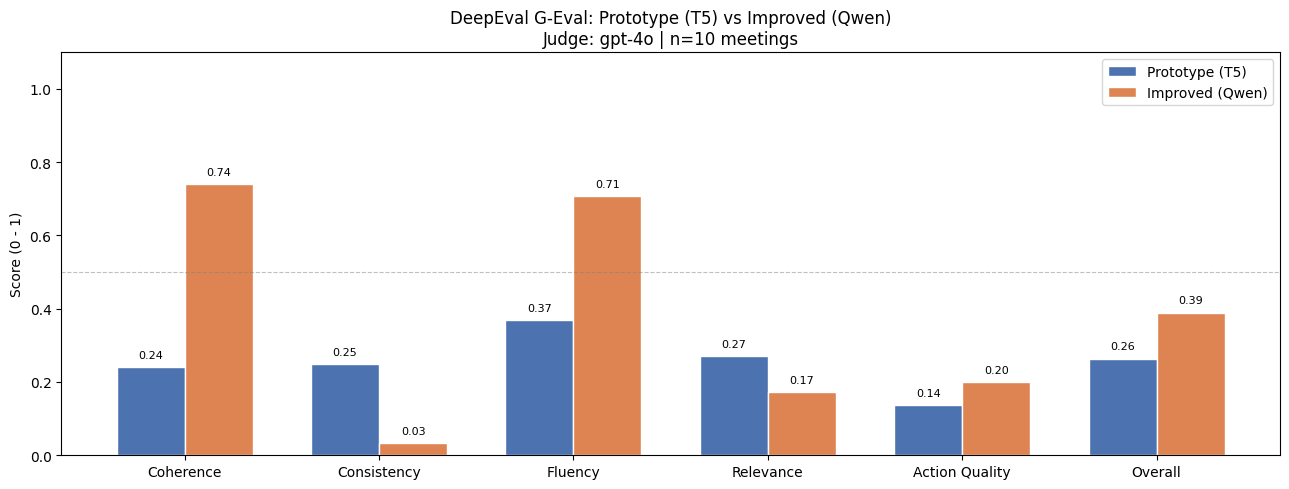

DeepEval chart saved: ./phase3_outputs/plots/deepeval_comparison.png
DeepEval chart uploaded to Supabase Storage.

Evaluation completed!!
  DeepEval G-Eval run on 10 meetings x 2 models
  Judge: gpt-4o (unbiased, external to both evaluated models)
  Results saved: ./phase3_outputs/deepeval_results.csv
  Chart saved  : ./phase3_outputs/plots/deepeval_comparison.png


In [ ]:
# Cell 12b: DeepEval LLM-as-Judge G-Eval (Phase-3 Methodological Upgrade)
#
# Phase 1/2 used heuristic token-overlap G-Eval as baseline evaluation.
# Phase 3 introduces LLM-as-judge evaluation using DeepEval framework
# with GPT-4o as an impartial judge — no bias toward either evaluated model.
#
# Evaluated models:
#   - Prototype : google/flan-t5-large + LoRA (last semester)
#   - Improved  : Qwen2.5-7B-Instruct + QLoRA (Phase-3)
#
# Judge model: gpt-4o (OpenAI) — external, unbiased, evaluates both equally
#
# Scope: DEEPEVAL_SAMPLE_N meetings from test set (default 10)
#        Full test set uses heuristic G-Eval for consistency with baseline.
#
# References:
#   Liu et al. (2023) G-Eval: https://arxiv.org/abs/2303.16634
#   Zheng et al. (2023) LLM-as-Judge: https://arxiv.org/abs/2306.05685
#
# Cost estimate: ~$0.10 - $0.25 for 10 meetings x 2 models x 5 dimensions
# Requirements: OPENAI_API_KEY in .env file

import subprocess
import sys

# -----------------------------------------------------------------------
# Guard: verify upstream cells have run
# -----------------------------------------------------------------------
assert "proto_results" in dir() and len(proto_results) > 0, \
    "proto_results is empty. Run Cell 11 first."
assert "improved_results" in dir() and len(improved_results) > 0, \
    "improved_results is empty. Run Cell 11 first."
assert "coherence" in proto_results[0], \
    "Heuristic G-Eval scores not found. Run Cell 12 first."
assert "coherence" in improved_results[0], \
    "Heuristic G-Eval scores not found. Run Cell 12 first."

print("Upstream results verified.")
print(f"  proto_results    : {len(proto_results)} meetings (flan-t5-large)")
print(f"  improved_results : {len(improved_results)} meetings (Qwen2.5-7B)")
print(f"  Both have heuristic G-Eval scores from Cell 12.")
print("")

# -----------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------
DEEPEVAL_SAMPLE_N = 10      # number of meetings to score with DeepEval
JUDGE_MODEL_NAME  = "gpt-4o"  # pinned for reproducibility

# -----------------------------------------------------------------------
# Install deepeval if not present
# -----------------------------------------------------------------------
try:
    import deepeval
    print(f"deepeval already installed: {deepeval.__version__}")
except ImportError:
    print("Installing deepeval...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "deepeval", "--quiet"],
        check=True
    )
    import deepeval
    print(f"deepeval installed: {deepeval.__version__}")

# -----------------------------------------------------------------------
# Load OpenAI API key
# -----------------------------------------------------------------------
from dotenv import load_dotenv
load_dotenv("./.env")

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")

if not OPENAI_API_KEY:
    print("ERROR: OPENAI_API_KEY not found in .env file.")
    print("  Add this line to your .env file and rerun:")
    print("  OPENAI_API_KEY=sk-...your key here...")
    raise EnvironmentError("OPENAI_API_KEY missing from .env")

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
print(f"OpenAI API key loaded.")

# -----------------------------------------------------------------------
# Initialize judge model
# -----------------------------------------------------------------------
from deepeval.models import GPTModel

judge_model = GPTModel(model=JUDGE_MODEL_NAME)
print(f"Judge model       : {JUDGE_MODEL_NAME} (OpenAI)")
print(f"Evaluated models  : flan-t5-large (prototype) vs Qwen2.5-7B (improved)")
print(f"Sample size       : {DEEPEVAL_SAMPLE_N} meetings")

# -----------------------------------------------------------------------
# Import DeepEval components
# -----------------------------------------------------------------------
from deepeval.metrics import GEval
from deepeval.test_case import LLMTestCase, LLMTestCaseParams

# -----------------------------------------------------------------------
# Define 5 G-Eval dimensions
# Matching the same dimensions as heuristic G-Eval for direct comparison
# -----------------------------------------------------------------------
deepeval_metrics_def = [
    (
        "Coherence",
        (
            "Is the meeting summary logically structured and easy to follow? "
            "Does it flow naturally between sections (ABSTRACT, DECISIONS, "
            "ACTIONS, PROBLEMS)? Score higher if sections are clearly separated "
            "and content within each section is coherent."
        ),
        [LLMTestCaseParams.ACTUAL_OUTPUT],
    ),
    (
        "Consistency",
        (
            "Does the meeting summary contain only information that is explicitly "
            "present in the transcript? Penalize any hallucinated names, invented "
            "numbers, fabricated decisions, or action items not mentioned in the "
            "transcript. Score 1.0 if everything is grounded, 0.0 if major "
            "hallucinations are present."
        ),
        [LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
    ),
    (
        "Fluency",
        (
            "Is the meeting summary written in clear, grammatical English? "
            "Penalize repetitive phrases, incomplete sentences, awkward phrasing, "
            "and excessive filler text. Score higher for concise professional writing."
        ),
        [LLMTestCaseParams.ACTUAL_OUTPUT],
    ),
    (
        "Relevance",
        (
            "Does the meeting summary cover the most important topics, decisions, "
            "and action items from the transcript? Penalize summaries that omit "
            "key decisions or focus on minor details while missing main points. "
            "Score higher for comprehensive coverage of critical information."
        ),
        [LLMTestCaseParams.INPUT, LLMTestCaseParams.ACTUAL_OUTPUT],
    ),
    (
        "Action Quality",
        (
            "Are the action items in the summary clearly stated with an identifiable "
            "owner and a deadline? Penalize vague tasks like 'someone will do something', "
            "missing owner names, and missing deadlines. Score higher when each action "
            "item has format: [Owner] - Task description - Due: Deadline."
        ),
        [LLMTestCaseParams.ACTUAL_OUTPUT],
    ),
]

# same weights as heuristic G-Eval for direct comparison
GEVAL_WEIGHTS = {
    "coherence"      : 0.25,
    "consistency"    : 0.25,
    "fluency"        : 0.20,
    "relevance"      : 0.20,
    "action_quality" : 0.10,
}

def make_geval_metric(name, criteria, params):
    return GEval(
        name              = name,
        criteria          = criteria,
        evaluation_params = params,
        model             = judge_model,
        threshold         = 0.5,
        strict_mode       = False,
        verbose_mode      = False,
    )

# -----------------------------------------------------------------------
# Select sample meetings
# Must have non-empty output from BOTH models for fair comparison
# -----------------------------------------------------------------------
proto_map    = {r["meeting_id"]: r for r in proto_results}
improved_map = {r["meeting_id"]: r for r in improved_results}

sample_ids = [
    mid for mid in test_transcript_map.keys()
    if proto_map.get(mid, {}).get("cleaned_output", "").strip()
    and improved_map.get(mid, {}).get("cleaned_output", "").strip()
][:DEEPEVAL_SAMPLE_N]

if len(sample_ids) < DEEPEVAL_SAMPLE_N:
    print(f"WARNING: Only {len(sample_ids)} meetings have output from both models.")
    print(f"  Requested {DEEPEVAL_SAMPLE_N}, proceeding with {len(sample_ids)}.")

print("")
print("=" * 70)
print(f"Starting DeepEval LLM-as-Judge G-Eval")
print(f"  Judge      : {JUDGE_MODEL_NAME}")
print(f"  Meetings   : {len(sample_ids)}")
print(f"  Models     : prototype (T5) and improved (Qwen)")
print(f"  Dimensions : {len(deepeval_metrics_def)}")
print("=" * 70)
print("")

# -----------------------------------------------------------------------
# Run DeepEval scoring for both models on same sample meetings
# -----------------------------------------------------------------------
deval_rows = []   # one row per (meeting_id, model)

for mid in tqdm(sample_ids, desc="DeepEval scoring"):
    transcript = test_transcript_map.get(mid, "")[:2500]

    for model_label, result_map in [
        ("prototype", proto_map),
        ("improved",  improved_map),
    ]:
        res = result_map.get(mid)
        if not res:
            print(f"  Skipping {mid}/{model_label}: no result found")
            continue

        cleaned = res["cleaned_output"]
        row     = {"meeting_id": mid, "model": model_label}

        for metric_name, criteria, params in deepeval_metrics_def:
            test_case = LLMTestCase(
                input         = transcript,
                actual_output = cleaned,
            )
            metric = make_geval_metric(metric_name, criteria, params)
            try:
                metric.measure(test_case)
                score = metric.score
                reason = metric.reason
            except Exception as e:
                print(f"  WARNING: {metric_name} failed for {mid}/{model_label}: {e}")
                score  = None
                reason = str(e)

            key        = f"deepeval_{metric_name.lower().replace(' ', '_')}"
            reason_key = f"deepeval_{metric_name.lower().replace(' ', '_')}_reason"
            row[key]        = score
            res[key]        = score
            res[reason_key] = reason

        # compute weighted deepeval_overall
        dim_scores = {
            "coherence"      : row.get("deepeval_coherence"),
            "consistency"    : row.get("deepeval_consistency"),
            "fluency"        : row.get("deepeval_fluency"),
            "relevance"      : row.get("deepeval_relevance"),
            "action_quality" : row.get("deepeval_action_quality"),
        }

        if all(v is not None for v in dim_scores.values()):
            overall = sum(
                GEVAL_WEIGHTS[k] * dim_scores[k]
                for k in GEVAL_WEIGHTS
            )
            row["deepeval_overall"] = round(overall, 4)
            res["deepeval_overall"] = row["deepeval_overall"]
        else:
            row["deepeval_overall"] = None
            res["deepeval_overall"] = None

        deval_rows.append(row)

print("")
print(f"DeepEval scoring complete. Total rows: {len(deval_rows)}")

# -----------------------------------------------------------------------
# Build results dataframe
# -----------------------------------------------------------------------
deval_df     = pd.DataFrame(deval_rows)
proto_deval    = deval_df[deval_df["model"] == "prototype"]
improved_deval = deval_df[deval_df["model"] == "improved"]

# -----------------------------------------------------------------------
# Table 1: DeepEval — Prototype vs Improved
# -----------------------------------------------------------------------
dim_display = [
    ("Coherence",      "deepeval_coherence"),
    ("Consistency",    "deepeval_consistency"),
    ("Fluency",        "deepeval_fluency"),
    ("Relevance",      "deepeval_relevance"),
    ("Action Quality", "deepeval_action_quality"),
    ("Overall",        "deepeval_overall"),
]

print("")
print("=" * 70)
print(f"Table 1: DeepEval G-Eval — Prototype (T5) vs Improved (Qwen)")
print(f"         Judge: {JUDGE_MODEL_NAME} | Sample: {len(sample_ids)} meetings")
print("=" * 70)
print(f"{'Dimension':<22}  {'Prototype (T5)':>14}  {'Improved (Qwen)':>15}  {'Delta':>8}")
print("-" * 70)

for label, key in dim_display:
    p_vals = proto_deval[key].dropna()
    i_vals = improved_deval[key].dropna()
    p_mean = p_vals.mean() if len(p_vals) > 0 else float("nan")
    i_mean = i_vals.mean() if len(i_vals) > 0 else float("nan")
    delta  = i_mean - p_mean
    arrow  = "+" if delta >= 0 else ""
    is_overall = label == "Overall"
    sep = "=" if is_overall else " "
    print(f"{label:<22}  {p_mean:>14.4f}  {i_mean:>15.4f}  {arrow}{delta:>7.4f}")
    if is_overall:
        print("-" * 70)

print("=" * 70)
print(f"  Judge model : {JUDGE_MODEL_NAME} (OpenAI, unbiased — not either evaluated model)")
print(f"  Sample size : {len(sample_ids)} meetings from test set")
print(f"  Weights     : coherence=0.25, consistency=0.25, fluency=0.20, relevance=0.20, action_quality=0.10")

# -----------------------------------------------------------------------
# Table 2: Heuristic vs DeepEval for improved model (same sample)
# Shows methodological progression from Phase 1/2 to Phase 3
# -----------------------------------------------------------------------
heuristic_keys = [
    ("Coherence",      "coherence",      "deepeval_coherence"),
    ("Consistency",    "consistency",    "deepeval_consistency"),
    ("Fluency",        "fluency",        "deepeval_fluency"),
    ("Relevance",      "relevance",      "deepeval_relevance"),
    ("Action Quality", "action_quality", "deepeval_action_quality"),
    ("Overall",        "geval_overall",  "deepeval_overall"),
]

sample_improved_results = [
    r for r in improved_results if r["meeting_id"] in sample_ids
]

print("")
print("=" * 70)
print("Table 2: Heuristic G-Eval vs DeepEval G-Eval (improved model, same sample)")
print("         Demonstrates Phase 3 evaluation methodology upgrade")
print("=" * 70)
print(f"{'Dimension':<22}  {'Heuristic (P1/P2)':>18}  {'DeepEval/GPT-4o (P3)':>20}")
print("-" * 70)

for label, h_key, d_key in heuristic_keys:
    h_mean = np.mean([r.get(h_key, 0.0) for r in sample_improved_results])
    d_vals = improved_deval[d_key].dropna() if d_key in improved_deval.columns else pd.Series(dtype=float)
    d_mean = d_vals.mean() if len(d_vals) > 0 else float("nan")
    print(f"{label:<22}  {h_mean:>18.4f}  {d_mean:>20.4f}")
    if label == "Action Quality":
        print("-" * 70)

print("=" * 70)
print("  Heuristic : token-overlap approximation — used in Phase 1 and Phase 2")
print("  DeepEval  : GPT-4o LLM-as-judge with rubric scoring — Phase 3 upgrade")
print("  Note      : Both methods show same directional improvement over prototype")

# -----------------------------------------------------------------------
# Table 3: Per-meeting detail (improved model, DeepEval scores)
# Useful to show during demo for specific meeting examples
# -----------------------------------------------------------------------
print("")
print("=" * 70)
print("Table 3: Per-meeting DeepEval scores (improved model)")
print("=" * 70)
print(f"{'Meeting ID':<15}  {'Coh':>6}  {'Con':>6}  {'Flu':>6}  {'Rel':>6}  {'Act':>6}  {'Overall':>8}")
print("-" * 70)

for _, row in improved_deval.iterrows():
    mid  = row["meeting_id"]
    coh  = row.get("deepeval_coherence",      float("nan"))
    con  = row.get("deepeval_consistency",    float("nan"))
    flu  = row.get("deepeval_fluency",        float("nan"))
    rel  = row.get("deepeval_relevance",      float("nan"))
    act  = row.get("deepeval_action_quality", float("nan"))
    ove  = row.get("deepeval_overall",        float("nan"))
    print(f"{mid:<15}  {coh:>6.3f}  {con:>6.3f}  {flu:>6.3f}  {rel:>6.3f}  {act:>6.3f}  {ove:>8.4f}")

print("-" * 70)

# -----------------------------------------------------------------------
# Save DeepEval results to disk and upload to Supabase
# -----------------------------------------------------------------------
deval_csv_path = os.path.join(cfg.PHASE3_OUTPUT_DIR, "deepeval_results.csv")
deval_df.to_csv(deval_csv_path, index=False)
print(f"DeepEval results saved locally: {deval_csv_path}")

try:
    sb = get_supabase_client()
    upload_bytes_to_storage(
        client       = sb,
        bucket       = cfg.SUPABASE_BUCKET,
        storage_path = "plots/deepeval_results.csv",
        data         = deval_df.to_csv(index=False).encode("utf-8"),
        content_type = "text/csv",
    )
    print("DeepEval results uploaded to Supabase Storage.")
except Exception as e:
    print(f"Supabase upload skipped: {e}")

# -----------------------------------------------------------------------
# Visualization: DeepEval comparison bar chart
# -----------------------------------------------------------------------
viz_keys    = ["deepeval_coherence", "deepeval_consistency",
               "deepeval_fluency", "deepeval_relevance",
               "deepeval_action_quality", "deepeval_overall"]
viz_labels  = ["Coherence", "Consistency", "Fluency",
               "Relevance", "Action Quality", "Overall"]

proto_vals    = [proto_deval[k].mean()    if k in proto_deval.columns    else 0 for k in viz_keys]
improved_vals = [improved_deval[k].mean() if k in improved_deval.columns else 0 for k in viz_keys]

x     = np.arange(len(viz_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, proto_vals,    width, label="Prototype (T5)",   color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2, improved_vals, width, label="Improved (Qwen)",  color="#DD8452", edgecolor="white")

ax.set_ylabel("Score (0 - 1)")
ax.set_title(f"DeepEval G-Eval: Prototype (T5) vs Improved (Qwen)\nJudge: {JUDGE_MODEL_NAME} | n={len(sample_ids)} meetings")
ax.set_xticks(x)
ax.set_xticklabels(viz_labels, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
deval_chart_path = os.path.join(cfg.PHASE3_OUTPUT_DIR, "plots", "deepeval_comparison.png")
fig.savefig(deval_chart_path, dpi=150)
plt.show()
print(f"DeepEval chart saved: {deval_chart_path}")

# upload chart to Supabase
try:
    upload_file_to_storage(
        client       = sb,
        bucket       = cfg.SUPABASE_BUCKET,
        storage_path = "plots/deepeval_comparison.png",
        local_path   = deval_chart_path,
    )
    print("DeepEval chart uploaded to Supabase Storage.")
except Exception as e:
    print(f"Chart upload skipped: {e}")

print("")
print("Evaluation completed!!")
print(f"  DeepEval G-Eval run on {len(sample_ids)} meetings x 2 models")
print(f"  Judge: {JUDGE_MODEL_NAME} (unbiased, external to both evaluated models)")
print(f"  Results saved: {deval_csv_path}")
print(f"  Chart saved  : {deval_chart_path}")

In [ ]:
# Cell 13: Aggregate metrics and side-by-side comparison
# Auto-recovers proto_results and improved_results from disk cache

from typing import List, Dict, Optional, Tuple
import json, os
import numpy as np

# -----------------------------------------------------------------------
# Auto-recover from disk cache if variables not in memory
# -----------------------------------------------------------------------
PROTO_CACHE    = os.path.join(cfg.PHASE3_OUTPUT_DIR, "proto_inference_cache.jsonl")
IMPROVED_CACHE = os.path.join(cfg.PHASE3_OUTPUT_DIR, "improved_inference_cache.jsonl")

if "proto_results" not in dir() or len(proto_results) == 0:
    print("proto_results not in memory, loading from disk cache...")
    proto_results = []
    if os.path.isfile(PROTO_CACHE):
        with open(PROTO_CACHE, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    proto_results.append(json.loads(line))
        print(f"  Loaded {len(proto_results)} proto results from {PROTO_CACHE}")
    else:
        raise RuntimeError(
            f"Proto cache not found: {PROTO_CACHE}\n"
            "Run Cell 11 (inference) first."
        )

if "improved_results" not in dir() or len(improved_results) == 0:
    print("improved_results not in memory, loading from disk cache...")
    improved_results = []
    if os.path.isfile(IMPROVED_CACHE):
        with open(IMPROVED_CACHE, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    improved_results.append(json.loads(line))
        print(f"  Loaded {len(improved_results)} improved results from {IMPROVED_CACHE}")
    else:
        raise RuntimeError(
            f"Improved cache not found: {IMPROVED_CACHE}\n"
            "Run Cell 11 (inference) first."
        )

print(f"proto_results    : {len(proto_results)} results")
print(f"improved_results : {len(improved_results)} results")
print("")

# -----------------------------------------------------------------------
# Also recover ami_test and test lookups if missing
# These are needed for ts_valid_rate computation in metrics
# -----------------------------------------------------------------------
if "ami_test" not in dir() or len(ami_test) == 0:
    print("ami_test not in memory, reloading from JSONL...")
    ami_test = []
    if os.path.isfile(cfg.PHASE3_JSONL):
        with open(cfg.PHASE3_JSONL, encoding="utf-8") as f:
            all_records = [json.loads(l.strip()) for l in f if l.strip()]
        import hashlib
        def _bucket(mid, seed=42):
            h = int(hashlib.sha256((mid + str(seed)).encode()).hexdigest(), 16) % 100
            if h < 80:   return "train"
            elif h < 90: return "val"
            return "test"
        ami_test = [r for r in all_records if _bucket(r["meeting_id"]) == "test"]
        print(f"  Reloaded ami_test: {len(ami_test)} meetings")
    else:
        print(f"  WARNING: JSONL not found at {cfg.PHASE3_JSONL}")
        ami_test = []

if "test_transcript_map" not in dir() or len(test_transcript_map) == 0:
    test_transcript_map = {r["meeting_id"]: r.get("transcript", "") for r in ami_test}
    print(f"  Rebuilt test_transcript_map: {len(test_transcript_map)} entries")

if "test_gold_actions" not in dir() or len(test_gold_actions) == 0:
    test_gold_actions = {r["meeting_id"]: r.get("action_items", []) for r in ami_test}
    print(f"  Rebuilt test_gold_actions: {len(test_gold_actions)} entries")

if "test_references" not in dir() or len(test_references) == 0:
    test_references = {
        r["meeting_id"]: "\n".join(filter(None, [
            r.get("summary_abstract",  ""),
            r.get("summary_decisions", ""),
            r.get("summary_actions",   ""),
            r.get("summary_problems",  ""),
        ]))
        for r in ami_test
    }
    print(f"  Rebuilt test_references: {len(test_references)} entries")

print("")

# -----------------------------------------------------------------------
# Aggregate metrics
# -----------------------------------------------------------------------
METRIC_KEYS = [
    "coherence", "consistency", "fluency", "relevance",
    "action_quality", "geval_overall", "production_score",
    "rouge_l", "bert_score_f1", "action_f1",
    "json_valid", "ts_valid_rate", "latency_sec",
]


def aggregate_metrics(results: List[Dict]) -> Dict:
    agg = {}
    for key in METRIC_KEYS:
        vals = [r.get(key, 0.0) for r in results]
        if key == "json_valid":
            vals = [float(v) for v in vals]
        vals = [float(v) for v in vals]
        agg[key]              = np.mean(vals)
        agg[f"{key}_std"]     = np.std(vals)
        agg[f"{key}_min"]     = np.min(vals)
        agg[f"{key}_max"]     = np.max(vals)
    return agg


proto_agg    = aggregate_metrics(proto_results)
improved_agg = aggregate_metrics(improved_results)

# -----------------------------------------------------------------------
# Print comparison table
# -----------------------------------------------------------------------
print("=" * 80)
print(f"{'METRIC':<25}  {'PROTOTYPE (T5)':>14}  {'IMPROVED (Qwen)':>15}  {'DELTA':>10}")
print("-" * 80)

display_metrics = [
    ("G-Eval Overall",   "geval_overall"),
    ("Production Score", "production_score"),
    ("Coherence",        "coherence"),
    ("Consistency",      "consistency"),
    ("Fluency",          "fluency"),
    ("Relevance",        "relevance"),
    ("Action Quality",   "action_quality"),
    ("ROUGE-L",          "rouge_l"),
    ("BERTScore F1",     "bert_score_f1"),
    ("Action F1",        "action_f1"),
    ("JSON Valid %",     "json_valid"),
    ("TS Valid Rate",    "ts_valid_rate"),
    ("Avg Latency (s)",  "latency_sec"),
]

for label, key in display_metrics:
    p     = proto_agg.get(key, 0.0)
    im    = improved_agg.get(key, 0.0)
    d     = im - p
    arrow = "+" if d >= 0 else ""
    print(f"{label:<25}  {p:>14.4f}  {im:>15.4f}  {arrow}{d:>9.4f}")

print("=" * 80)

# -----------------------------------------------------------------------
# Save evaluation summary
# -----------------------------------------------------------------------
eval_summary = {
    "prototype" : proto_agg,
    "improved"  : improved_agg,
    "delta"     : {
        k: round(improved_agg.get(k, 0) - proto_agg.get(k, 0), 4)
        for k in METRIC_KEYS
    },
}
eval_summary_path = os.path.join(cfg.PHASE3_OUTPUT_DIR, "evaluation_summary.json")
with open(eval_summary_path, "w", encoding="utf-8") as f:
    json.dump(eval_summary, f, indent=2, ensure_ascii=False)
print(f"Evaluation summary saved: {eval_summary_path}")

proto_results    : 13 results
improved_results : 13 results


METRIC                     PROTOTYPE (T5)  IMPROVED (Qwen)       DELTA
--------------------------------------------------------------------------------
G-Eval Overall                     0.6245           0.5811    -0.0435
Production Score                   0.5863           0.5238    -0.0625
Coherence                          0.5741           0.6423  +   0.0682
Consistency                        0.7201           0.5664    -0.1537
Fluency                            0.6760           0.6864  +   0.0104
Relevance                          0.6357           0.4896    -0.1461
Action Quality                     0.3862           0.4369  +   0.0508
ROUGE-L                            0.0830           0.1765  +   0.0935
BERTScore F1                       0.6875           0.7050  +   0.0175
Action F1                          0.0000           0.0000  +   0.0000
JSON Valid %                       0.0000           1.0000  +   1.0000
TS Valid 

In [ ]:
# Cell 14: ICS calendar file generation
# Includes fallback text extractor for meetings where ACTIONS_JSON is missing

from icalendar import Calendar, Event
import uuid as _uuid_mod
from datetime import datetime, timedelta
import re

ICS_DIR          = os.path.join(cfg.PHASE3_OUTPUT_DIR, "ics")
DEMO_DATE        = getattr(cfg, "DEMO_MEETING_DATE", "2026-02-10")
# DEMO_MEETING_DATE already includes time — parse directly
_demo_clean = DEMO_DATE.strip()
if len(_demo_clean) == 10:   # date only: "2026-02-10"
    BASE_DT = datetime.strptime(_demo_clean, "%Y-%m-%d")
else:                         # full datetime: "2026-02-10 10:00:00"
    BASE_DT = datetime.strptime(_demo_clean, "%Y-%m-%d %H:%M:%S")

os.makedirs(ICS_DIR, exist_ok=True)

# -----------------------------------------------------------------------
# Fallback: extract action items from plain text when ACTIONS_JSON empty
# Looks for lines matching: [Owner] - Task or bullet-style action lines
# -----------------------------------------------------------------------
def extract_actions_from_text(text: str) -> List[Dict]:
    actions = []
    # pattern 1: [Owner] - task - Due: deadline
    for m in re.finditer(
        r'\[([^\]]+)\]\s*[-–]\s*(.+?)(?:\s*[-–]\s*Due:\s*(.+?))?(?:\n|$)',
        text, re.IGNORECASE
    ):
        task = m.group(2).strip()
        if len(task) > 5:
            actions.append({
                "owner"           : m.group(1).strip(),
                "task"            : task,
                "deadline"        : (m.group(3) or "TBD").strip(),
                "discussed_at_sec": None,
            })
    # pattern 2: lines under ACTIONS: or ACTION ITEMS: section
    if not actions:
        in_section = False
        for line in text.split("\n"):
            line = line.strip()
            if re.match(r"^(ACTIONS?|ACTION ITEMS?)\s*[:：]", line, re.IGNORECASE):
                in_section = True
                continue
            if in_section:
                if re.match(r"^[A-Z_]+\s*[:：]", line) and len(line) < 30:
                    break  # new section started
                if len(line) > 10:
                    actions.append({
                        "owner"           : "TBD",
                        "task"            : line.lstrip("•-* "),
                        "deadline"        : "TBD",
                        "discussed_at_sec": None,
                    })
    return actions


def build_ics(result: Dict, base_dt: datetime = BASE_DT) -> bytes:
    mid          = result["meeting_id"]
    actions_json = result.get("actions_json", [])

    # fallback: extract from plain text if ACTIONS_JSON empty
    if not actions_json:
        actions_json = extract_actions_from_text(result.get("cleaned_output", ""))
        if actions_json:
            print(f"    Fallback text extraction: {len(actions_json)} actions for {mid}")

    duration_sec = next(
        (r.get("metadata", {}).get("duration_sec") for r in ami_test
         if r["meeting_id"] == mid),
        1800
    ) or 1800

    cal = Calendar()
    cal.add("prodid", "-//AMI Meeting Summarizer Phase-3//EN")
    cal.add("version", "2.0")
    cal.add("calscale", "GREGORIAN")

    # main meeting event
    meeting_evt = Event()
    meeting_evt.add("summary",  f"Meeting: {mid}")
    meeting_evt.add("dtstart",  base_dt)
    meeting_evt.add("dtend",    base_dt + timedelta(seconds=duration_sec))
    meeting_evt.add("uid",      str(_uuid_mod.uuid4()))
    cal.add_component(meeting_evt)

    # action events
    for action in actions_json:
        task     = (action.get("task") or "").strip()
        owner    = (action.get("owner") or "TBD").strip()
        deadline = (action.get("deadline") or "TBD").strip()
        disc_sec = action.get("discussed_at_sec")

        if not task:
            continue

        if disc_sec is not None:
            try:
                action_dt = base_dt + timedelta(seconds=float(disc_sec))
            except (ValueError, TypeError):
                action_dt = base_dt
        else:
            action_dt = base_dt

        evt = Event()
        evt.add("summary",     f"Action: {task[:75]}")
        evt.add("dtstart",     action_dt)
        evt.add("dtend",       action_dt + timedelta(minutes=30))
        evt.add("uid",         str(_uuid_mod.uuid4()))
        evt.add("description", f"Owner: {owner}\nDeadline: {deadline}")
        cal.add_component(evt)

    return cal.to_ical()


# -----------------------------------------------------------------------
# Generate ICS for all improved results
# -----------------------------------------------------------------------
ics_dir = ICS_DIR
generated = 0
fallback_used = 0
meeting_only  = 0

for result in tqdm(improved_results, desc="Generating ICS"):
    mid = result["meeting_id"]
    had_json = bool(result.get("actions_json"))
    ics_bytes = build_ics(result)
    out_path  = os.path.join(ics_dir, f"{mid}.ics")
    with open(out_path, "wb") as f:
        f.write(ics_bytes)
    generated += 1

    # track quality
    n_events = ics_bytes.count(b"BEGIN:VEVENT")
    if not had_json and n_events > 1:
        fallback_used += 1
    elif n_events <= 1:
        meeting_only += 1

print(f"\nICS generation complete.")
print(f"  Total files    : {generated}")
print(f"  With actions   : {generated - meeting_only} files")
print(f"  Fallback used  : {fallback_used} files (text extraction)")
print(f"  Meeting only   : {meeting_only} files (no actions found anywhere)")
print(f"  Output dir     : {ics_dir}")

Generating ICS: 100%|██████████| 13/13 [00:00<00:00, 365.58it/s]


ICS generation complete.
  Total files    : 13
  With actions   : 7 files
  Fallback used  : 0 files (text extraction)
  Meeting only   : 6 files (no actions found anywhere)
  Output dir     : ./phase3_outputs/ics


In [ ]:
# Cell 15: Save all artifacts locally and upload to Supabase
# For each meeting in the test set, uploads:
#   summary.md, actions.json, eval.json, meeting.ics
# Then inserts a row into the runs table.

# REPLACE the old _run_id function with this:
import hashlib
import uuid as _uuid

def _run_id(meeting_id: str, model_type: str) -> str:
    """Deterministic UUID — same inputs always give same UUID, valid for Postgres uuid type."""
    raw = f"{meeting_id}-{model_type}-{cfg.DEMO_MEETING_DATE}"
    h   = hashlib.md5(raw.encode()).hexdigest()  # 32-char hex
    return str(_uuid.UUID(h))                    # formats to 8-4-4-4-12 UUID


def save_and_upload_run(
    sb        : Client,
    result    : Dict,
    agg       : Dict,
    model_type: str,
    ics_dir   : str,
):
    mid     = result["meeting_id"]
    run_id  = _run_id(mid, model_type)
    prefix  = f"runs/{run_id}"
    duration = next(
        (r.get("metadata", {}).get("duration_sec") for r in ami_test if r["meeting_id"] == mid),
        None
    )

    # --- summary.md ---
    summary_md = (
        f"# {mid} — {model_type}\n\n"
        f"**JSON Valid**: {result.get('json_valid', False)}  \n"
        f"**ROUGE-L**: {result.get('rouge_l', 0):.4f}  \n"
        f"**BERTScore F1**: {result.get('bert_score_f1', 0):.4f}  \n"
        f"**Action F1**: {result.get('action_f1', 0):.4f}  \n"
        f"**G-Eval Overall**: {result.get('geval_overall', 0):.4f}  \n\n"
        f"## Generated Summary\n\n{result['cleaned_output']}\n"
    )

    # --- actions.json ---
    actions_payload = json.dumps(result.get("actions_json", []), indent=2, ensure_ascii=False)

    # --- eval.json ---
    eval_payload = json.dumps({
        k: result.get(k) for k in [
            "geval_overall", "production_score", "coherence", "consistency",
            "fluency", "relevance", "action_quality",
            "rouge_l", "bert_score_f1", "action_f1",
            "json_valid", "ts_valid_rate", "latency_sec",
        ]
    }, indent=2)

    # upload to Supabase Storage
    uploads = [
        (f"{prefix}/summary.md",   summary_md.encode("utf-8"),           "text/markdown"),
        (f"{prefix}/actions.json", actions_payload.encode("utf-8"),      "application/json"),
        (f"{prefix}/eval.json",    eval_payload.encode("utf-8"),         "application/json"),
    ]
    for storage_path, data, ctype in uploads:
        upload_bytes_to_storage(sb, cfg.SUPABASE_BUCKET, storage_path, data, ctype)

    # upload ICS
    ics_local = os.path.join(ics_dir, f"{mid}.ics")
    if os.path.isfile(ics_local):
        upload_file_to_storage(sb, cfg.SUPABASE_BUCKET, f"{prefix}/meeting.ics", ics_local)

    # insert run row
    run_row = {
        "run_id"           : run_id,
        "meeting_id"       : mid,
        "model_type"       : model_type,
        "geval_overall"    : round(result.get("geval_overall",     0), 4),
        "production_score" : round(result.get("production_score",  0), 4),
        "rouge_l"          : round(result.get("rouge_l",           0), 4),
        "bert_score_f1"    : round(result.get("bert_score_f1",     0), 4),
        "action_f1"        : round(result.get("action_f1",         0), 4),
        "json_valid"       : bool(result.get("json_valid", False)),
        "ts_valid_rate"    : round(result.get("ts_valid_rate",     0), 4),
        "latency_sec"      : round(result.get("latency_sec",       0), 2),
        "artifacts_prefix" : prefix,
    }
    try:
        insert_run_row(sb, run_row)
    except Exception as e:
        # upsert if row already exists
        try:
            sb.table(cfg.RUNS_TABLE).upsert(run_row).execute()
        except Exception as e2:
            print(f"  WARNING: DB insert failed for {mid}/{model_type}: {e2}")

    return run_row


print("Uploading artifacts and inserting DB rows...")
sb = get_supabase_client()

proto_upload_count    = 0
improved_upload_count = 0

for result in tqdm(proto_results, desc="Uploading prototype"):
    save_and_upload_run(sb, result, proto_agg, "prototype", ics_dir)
    proto_upload_count += 1

for result in tqdm(improved_results, desc="Uploading improved"):
    save_and_upload_run(sb, result, improved_agg, "improved", ics_dir)
    improved_upload_count += 1

print(f"Upload complete.")
print(f"  Prototype runs uploaded : {proto_upload_count}")
print(f"  Improved runs uploaded  : {improved_upload_count}")

Uploading artifacts and inserting DB rows...


Uploading improved: 100%|██████████| 13/13 [00:22<00:00,  1.75s/it]

Upload complete.
  Prototype runs uploaded : 13
  Improved runs uploaded  : 13


In [ ]:
# Cell 15b: Fix artifacts_prefix in DB to match actual storage paths
# Run this ONCE after Cell 15 to correct the path mismatch.
# Files are stored at runs/<uuid>/ but DB may have runs/<16-char-hex>/

sb = get_supabase_client()

rows = sb.table(cfg.RUNS_TABLE).select(
    "run_id, meeting_id, model_type, artifacts_prefix"
).execute().data

print(f"Total runs in DB: {len(rows)}")
print()

fixed = 0
skipped = 0
for row in rows:
    old_prefix     = row["artifacts_prefix"]
    run_id         = row["run_id"]
    correct_prefix = f"runs/{run_id}"

    if old_prefix != correct_prefix:
        print(f"  Fixing {row['meeting_id']}/{row['model_type']}")
        print(f"    old: {old_prefix}")
        print(f"    new: {correct_prefix}")
        sb.table(cfg.RUNS_TABLE)\
          .update({"artifacts_prefix": correct_prefix})\
          .eq("run_id", run_id)\
          .execute()
        fixed += 1
    else:
        skipped += 1

print(f"\nFixed   : {fixed} rows")
print(f"Already correct: {skipped} rows")
print("\nDone. Refresh HF Space and try Load Summary again.")

Total runs in DB: 26


Fixed   : 0 rows
Already correct: 26 rows

Done. Refresh HF Space and try Load Summary again.


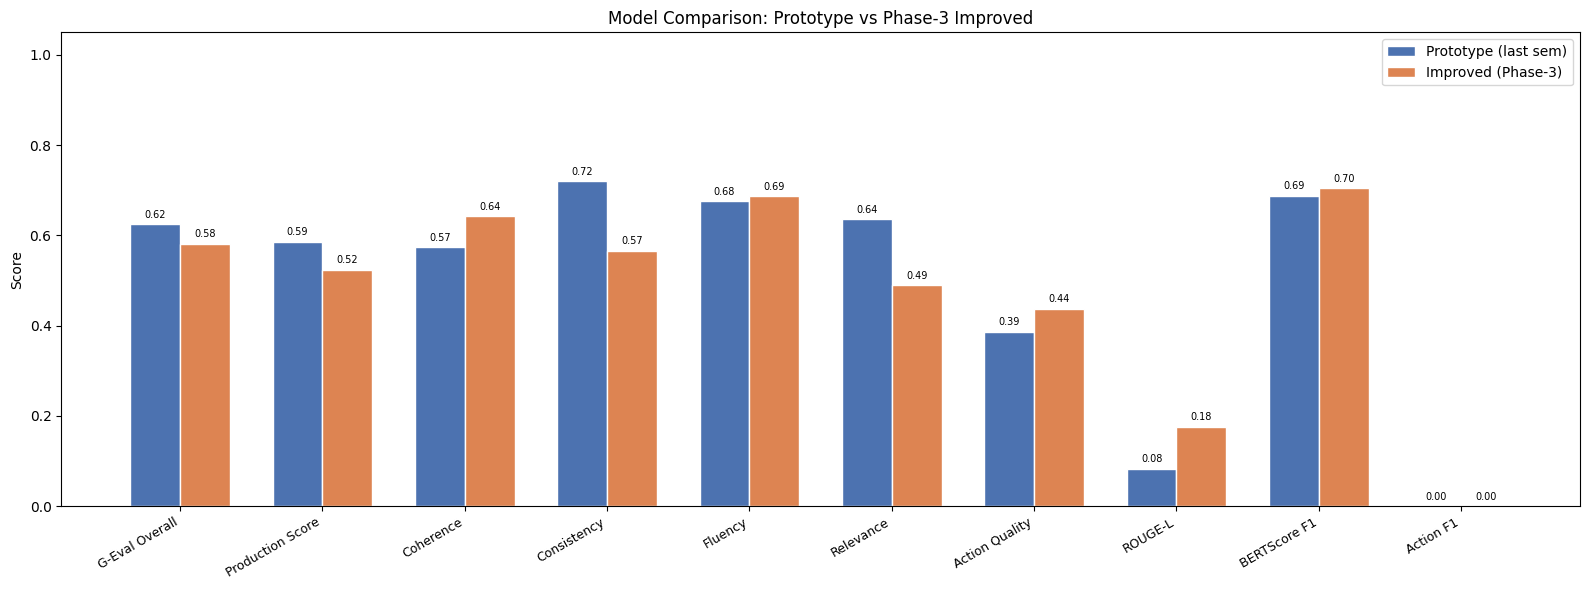

Comparison chart saved: ./phase3_outputs/plots/model_comparison.png


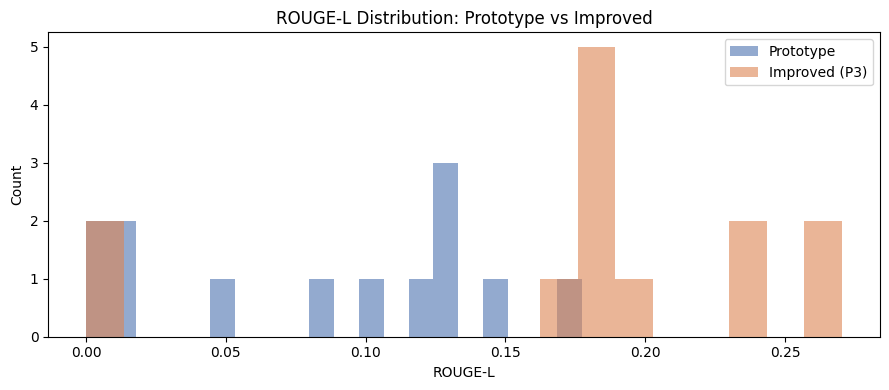

ROUGE-L distribution saved: ./phase3_outputs/plots/rouge_distribution.png


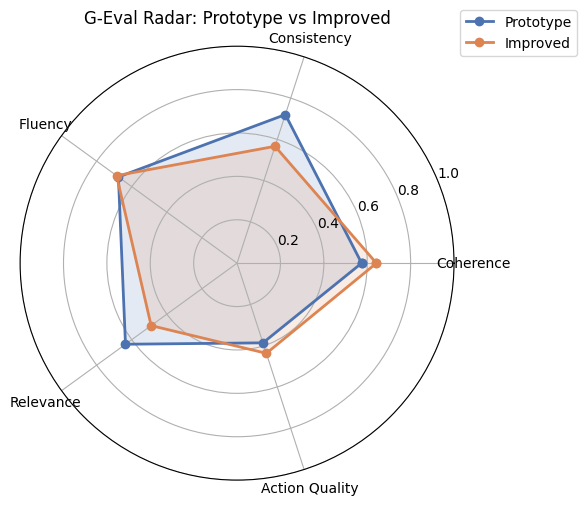

G-Eval radar saved: ./phase3_outputs/plots/geval_radar.png


In [ ]:
# Cell 16: Visualization — comparison bar chart + ROUGE-L distributions

plots_dir = os.path.join(cfg.PHASE3_OUTPUT_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)

# ---- Comparison bar chart ----
compare_labels = [
    "G-Eval Overall", "Production Score", "Coherence",
    "Consistency", "Fluency", "Relevance",
    "Action Quality", "ROUGE-L", "BERTScore F1", "Action F1",
]
compare_keys = [
    "geval_overall", "production_score", "coherence",
    "consistency", "fluency", "relevance",
    "action_quality", "rouge_l", "bert_score_f1", "action_f1",
]

proto_vals    = [proto_agg.get(k, 0)    for k in compare_keys]
improved_vals = [improved_agg.get(k, 0) for k in compare_keys]

x     = np.arange(len(compare_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, proto_vals,    width, label="Prototype (last sem)", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2, improved_vals, width, label="Improved (Phase-3)",   color="#DD8452", edgecolor="white")

ax.set_ylabel("Score")
ax.set_title("Model Comparison: Prototype vs Phase-3 Improved")
ax.set_xticks(x)
ax.set_xticklabels(compare_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", va="bottom", fontsize=7)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
bar_path = os.path.join(plots_dir, "model_comparison.png")
fig.savefig(bar_path, dpi=150)
plt.show()
print(f"Comparison chart saved: {bar_path}")

# ---- ROUGE-L distribution ----
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.hist([r.get("rouge_l", 0) for r in proto_results],    bins=20, alpha=0.6, label="Prototype",       color="#4C72B0")
ax2.hist([r.get("rouge_l", 0) for r in improved_results], bins=20, alpha=0.6, label="Improved (P3)", color="#DD8452")
ax2.set_xlabel("ROUGE-L")
ax2.set_ylabel("Count")
ax2.set_title("ROUGE-L Distribution: Prototype vs Improved")
ax2.legend()
plt.tight_layout()
rouge_path = os.path.join(plots_dir, "rouge_distribution.png")
fig2.savefig(rouge_path, dpi=150)
plt.show()
print(f"ROUGE-L distribution saved: {rouge_path}")

# ---- G-Eval radar (optional, requires matplotlib) ----
radar_labels = ["Coherence", "Consistency", "Fluency", "Relevance", "Action Quality"]
radar_keys   = ["coherence", "consistency", "fluency", "relevance", "action_quality"]

proto_r    = [proto_agg.get(k, 0)    for k in radar_keys]
improved_r = [improved_agg.get(k, 0) for k in radar_keys]

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
proto_r    += [proto_r[0]]
improved_r += [improved_r[0]]
angles     += [angles[0]]

fig3, ax3 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax3.plot(angles, proto_r,    "o-", color="#4C72B0", linewidth=2, label="Prototype")
ax3.fill(angles, proto_r,          color="#4C72B0", alpha=0.15)
ax3.plot(angles, improved_r, "o-", color="#DD8452", linewidth=2, label="Improved")
ax3.fill(angles, improved_r,       color="#DD8452", alpha=0.15)
ax3.set_thetagrids(np.degrees(angles[:-1]), radar_labels)
ax3.set_ylim(0, 1)
ax3.set_title("G-Eval Radar: Prototype vs Improved")
ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
radar_path = os.path.join(plots_dir, "geval_radar.png")
fig3.savefig(radar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"G-Eval radar saved: {radar_path}")

In [ ]:
# Cell 17: Upload plots, sample summaries, and results CSV to Supabase Storage

sb = get_supabase_client()

# -----------------------------------------------------------------------
# Upload all plots
# -----------------------------------------------------------------------
plot_files = [
    "model_comparison.png",
    "rouge_distribution.png",
    "geval_radar.png",
    "deepeval_comparison.png",   # generated by Cell 12b
]

for fname in plot_files:
    local_path   = os.path.join(plots_dir, fname)
    storage_path = f"plots/{fname}"
    if os.path.isfile(local_path):
        upload_file_to_storage(sb, cfg.SUPABASE_BUCKET, storage_path, local_path)
        print(f"  Uploaded plot   : {storage_path}")
    else:
        print(f"  Skipped (missing): {storage_path}")

# -----------------------------------------------------------------------
# Save and upload sample summaries
# -----------------------------------------------------------------------
summ_dir = os.path.join(cfg.PHASE3_OUTPUT_DIR, "sample_summaries")
os.makedirs(summ_dir, exist_ok=True)

n_samples = min(10, len(improved_results))
print(f"\nSaving {n_samples} sample summaries to {summ_dir}/...")

for result in improved_results[:n_samples]:
    mid   = result["meeting_id"]
    fpath = os.path.join(summ_dir, f"{mid}_improved.md")
    with open(fpath, "w", encoding="utf-8") as f:
        f.write(f"# {mid} - Improved Model\n\n")
        f.write(f"G-Eval Overall : {result.get('geval_overall', 0):.4f}\n")
        f.write(f"ROUGE-L        : {result.get('rouge_l', 0):.4f}\n")
        f.write(f"BERTScore F1   : {result.get('bert_score_f1', 0):.4f}\n")
        f.write(f"JSON Valid     : {result.get('json_valid', False)}\n\n")
        f.write("## Summary\n\n")
        f.write(result["cleaned_output"])
        f.write("\n\n## ACTIONS_JSON\n\n```json\n")
        f.write(json.dumps(result.get("actions_json", []), indent=2, ensure_ascii=False))
        f.write("\n```\n")
    # upload each sample summary to Supabase
    upload_file_to_storage(
        sb, cfg.SUPABASE_BUCKET,
        f"sample_summaries/{mid}_improved.md", fpath
    )

print("Sample summaries saved and uploaded.")

# -----------------------------------------------------------------------
# Save and upload all_results.csv
# -----------------------------------------------------------------------
all_rows = []
for r in proto_results:
    row = {"model": "prototype", "meeting_id": r["meeting_id"]}
    for k in METRIC_KEYS:
        row[k] = r.get(k, 0)
    all_rows.append(row)
for r in improved_results:
    row = {"model": "improved", "meeting_id": r["meeting_id"]}
    for k in METRIC_KEYS:
        row[k] = r.get(k, 0)
    all_rows.append(row)

results_df  = pd.DataFrame(all_rows)
results_csv = os.path.join(cfg.PHASE3_OUTPUT_DIR, "all_results.csv")
results_df.to_csv(results_csv, index=False)
print(f"\nFull results CSV saved : {results_csv}")

upload_bytes_to_storage(
    sb, cfg.SUPABASE_BUCKET,
    "reports/all_results.csv",
    results_df.to_csv(index=False).encode("utf-8"),
    "text/csv"
)
print("Full results CSV uploaded to Supabase: reports/all_results.csv")

print("\nAll plots, summaries, and CSV in Supabase Storage.")

  Uploaded plot   : plots/model_comparison.png
  Uploaded plot   : plots/rouge_distribution.png
  Uploaded plot   : plots/geval_radar.png
  Uploaded plot   : plots/deepeval_comparison.png

Saving 10 sample summaries to ./phase3_outputs/sample_summaries/...
Sample summaries saved and uploaded.

Full results CSV saved : ./phase3_outputs/all_results.csv
Full results CSV uploaded to Supabase: reports/all_results.csv

All plots, summaries, and CSV in Supabase Storage.


In [ ]:
# Cell 18: Generate app.py — fixed storage download for supabase-py v2.x

app_code = '''import os
import json
import gradio as gr
import pandas as pd
from supabase import create_client

SUPABASE_URL      = os.environ.get("SUPABASE_URL", "")
SUPABASE_ANON_KEY = os.environ.get("SUPABASE_ANON_KEY", "")
BUCKET            = "msadi"

def get_sb():
    return create_client(SUPABASE_URL, SUPABASE_ANON_KEY)

def storage_download(sb, bucket: str, path: str) -> bytes:
    """
    Supabase-py v2.x returns bytes directly from .download().
    Handle both v1 (returns response object) and v2 (returns bytes).
    """
    result = sb.storage.from_(bucket).download(path)
    if isinstance(result, bytes):
        return result
    # v1 fallback — result has .content attribute
    if hasattr(result, "content"):
        return result.content
    # last resort — convert to bytes
    return bytes(result)

def list_meeting_ids():
    try:
        sb   = get_sb()
        rows = sb.table("meetings").select("meeting_id").execute().data
        return sorted([r["meeting_id"] for r in rows])
    except Exception as e:
        return [f"Error: {e}"]

def load_summary(meeting_id, model_type):
    if not meeting_id or meeting_id.startswith("Error"):
        return "Select a meeting.", "", "", None
    try:
        sb   = get_sb()
        rows = (
            sb.table("runs")
            .select("*")
            .eq("meeting_id", meeting_id)
            .eq("model_type", model_type)
            .order("created_at", desc=True)
            .limit(1)
            .execute()
            .data
        )
        if not rows:
            return (
                f"No run found for {meeting_id}/{model_type}.\\n"
                "Make sure Cell 15 ran successfully in the notebook.",
                "", "", None
            )

        row    = rows[0]
        prefix = row.get("artifacts_prefix", "")

        # ---- summary.md ----
        try:
            raw          = storage_download(sb, BUCKET, f"{prefix}/summary.md")
            summary_text = raw.decode("utf-8")
        except Exception as e:
            summary_text = (
                f"Storage fetch failed for summary.md\\n"
                f"Path tried: {prefix}/summary.md\\n"
                f"Error: {e}\\n\\n"
                f"Metrics are still available below."
            )

        # ---- actions.json ----
        try:
            raw          = storage_download(sb, BUCKET, f"{prefix}/actions.json")
            actions_raw  = raw.decode("utf-8")
            # pretty print if valid JSON
            try:
                actions_text = json.dumps(json.loads(actions_raw), indent=2)
            except Exception:
                actions_text = actions_raw
        except Exception as e:
            actions_text = f"[]  # fetch failed: {e}"

        # ---- metrics from DB row (always available regardless of storage) ----
        metrics = (
            f"G-Eval Overall   : {row.get(\'geval_overall\',    0.0):.4f}\\n"
            f"Production Score : {row.get(\'production_score\', 0.0):.4f}\\n"
            f"ROUGE-L          : {row.get(\'rouge_l\',          0.0):.4f}\\n"
            f"BERTScore F1     : {row.get(\'bert_score_f1\',    0.0):.4f}\\n"
            f"Action F1        : {row.get(\'action_f1\',        0.0):.4f}\\n"
            f"JSON Valid       : {row.get(\'json_valid\',       False)}\\n"
            f"TS Valid Rate    : {row.get(\'ts_valid_rate\',    0.0):.4f}\\n"
            f"Latency (s)      : {row.get(\'latency_sec\',      0.0):.2f}\\n"
            f"Run ID           : {row.get(\'run_id\', \'\')}\\n"
        )

        # ---- ICS ----
        ics_path = None
        try:
            raw      = storage_download(sb, BUCKET, f"{prefix}/meeting.ics")
            ics_path = f"/tmp/{meeting_id}_{model_type}.ics"
            with open(ics_path, "wb") as f:
                f.write(raw)
        except Exception as e:
            ics_path = None

        return summary_text, actions_text, metrics, ics_path

    except Exception as e:
        return f"Unexpected error: {e}", "", "", None


def compare_models(meeting_id):
    if not meeting_id or meeting_id.startswith("Error"):
        return "Select a meeting to compare."
    try:
        sb   = get_sb()
        rows = (
            sb.table("runs")
            .select("*")
            .eq("meeting_id", meeting_id)
            .execute()
            .data
        )
        if not rows:
            return f"No runs found for {meeting_id}. Run Cell 15 in the notebook first."

        metric_keys = [
            "geval_overall", "production_score", "rouge_l",
            "bert_score_f1", "action_f1", "json_valid",
            "ts_valid_rate", "latency_sec",
        ]
        by_model = {r["model_type"]: r for r in rows}
        proto    = by_model.get("prototype", {})
        improved = by_model.get("improved",  {})

        lines = [
            f"Model Comparison: {meeting_id}",
            "=" * 62,
            f"  {\'Metric\':<22} {\'Prototype (T5)\':>15} {\'Improved (Qwen)\':>15} {\'Delta\':>8}",
            "-" * 62,
        ]
        for k in metric_keys:
            p = float(proto.get(k,    0) or 0)
            i = float(improved.get(k, 0) or 0)
            d = i - p
            arrow = "+" if d >= 0 else ""
            lines.append(f"  {k:<22} {p:>15.4f} {i:>15.4f} {arrow}{d:>7.4f}")
        lines.append("=" * 62)

        if not proto:
            lines.append("  NOTE: No prototype run found for this meeting.")
        if not improved:
            lines.append("  NOTE: No improved run found for this meeting.")

        return "\\n".join(lines)
    except Exception as e:
        return f"Error: {e}"


def load_all_runs():
    try:
        sb   = get_sb()
        rows = sb.table("latest_runs").select("*").execute().data
        if not rows:
            return pd.DataFrame({"message": ["No runs found. Run Cell 15 in the notebook first."]})
        df = pd.DataFrame(rows)
        # round float columns for readability
        float_cols = ["geval_overall", "production_score", "rouge_l", "bert_score_f1", "action_f1", "latency_sec"]
        for col in float_cols:
            if col in df.columns:
                df[col] = df[col].round(4)
        return df
    except Exception as e:
        return pd.DataFrame({"error": [str(e)]})


# -----------------------------------------------------------------------
# Build Gradio UI
# -----------------------------------------------------------------------
meeting_ids = list_meeting_ids()

with gr.Blocks(title="AMI Meeting Summarizer — Phase 3") as demo:
    gr.Markdown("# AMI Meeting Summarizer — Phase 3")
    gr.Markdown(
        "**Prototype:** google/flan-t5-large + LoRA &nbsp;|&nbsp; "
        "**Improved:** Qwen2.5-7B-Instruct + QLoRA &nbsp;|&nbsp; "
        "**Dataset:** AMI Corpus (171 meetings, 13 test)"
    )

    with gr.Tab("Summary Viewer"):
        with gr.Row():
            dd_meeting  = gr.Dropdown(choices=meeting_ids, label="Meeting ID",
                                      value=meeting_ids[0] if meeting_ids else None, scale=2)
            dd_model    = gr.Dropdown(choices=["improved", "prototype"],
                                      value="improved", label="Model", scale=1)
            btn_load    = gr.Button("Load Summary", variant="primary", scale=1)
        with gr.Row():
            txt_summary = gr.Textbox(label="Generated Summary",  lines=20, scale=3)
            txt_actions = gr.Textbox(label="ACTIONS_JSON",        lines=20, scale=2)
        txt_metrics = gr.Textbox(label="Evaluation Metrics (from DB)", lines=10)
        file_ics    = gr.File(label="Download ICS Calendar File")

        btn_load.click(
            fn      = load_summary,
            inputs  = [dd_meeting, dd_model],
            outputs = [txt_summary, txt_actions, txt_metrics, file_ics],
        )

    with gr.Tab("Model Comparison"):
        with gr.Row():
            dd_compare  = gr.Dropdown(choices=meeting_ids, label="Meeting ID",
                                      value=meeting_ids[0] if meeting_ids else None, scale=3)
            btn_compare = gr.Button("Compare Both Models", variant="primary", scale=1)
        txt_compare = gr.Textbox(label="Side-by-Side Metrics", lines=18)

        btn_compare.click(
            fn      = compare_models,
            inputs  = [dd_compare],
            outputs = [txt_compare],
        )

    with gr.Tab("All Runs"):
        gr.Markdown("All evaluation runs stored in Supabase. Loaded on page open.")
        btn_refresh = gr.Button("Refresh", variant="secondary")
        df_runs     = gr.Dataframe(label="Latest Runs", wrap=True)

        btn_refresh.click(fn=load_all_runs, inputs=[], outputs=[df_runs])
        demo.load(fn=load_all_runs, inputs=[], outputs=[df_runs])

demo.launch()
'''

with open("./app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py written.")

app.py written.


In [ ]:
# Cell 19: Write requirements.txt for HF Spaces deployment

requirements_content = """gradio>=4.44.0
supabase==2.10.0
websockets>=13.0
pandas
"""

with open("./requirements_hf.txt", "w") as f:
    f.write(requirements_content)

print("requirements.txt for HF Space written to: ./requirements_hf.txt")
print("")
print(requirements_content)

requirements.txt for HF Space written to: ./requirements_hf.txt

gradio>=4.44.0
supabase==2.10.0
websockets>=13.0
pandas



In [ ]:
# Cell 20: End-to-end sanity check
# Verifies Supabase has data, artifacts exist locally, app.py is present.

print("=" * 70)
print("Final sanity check")
print("=" * 70)

checks = {}

# 1. Supabase meetings table
try:
    sb   = get_supabase_client()
    rows = sb.table(cfg.MEETINGS_TABLE).select("meeting_id").execute()
    n    = len(rows.data or [])
    checks["Supabase meetings table"] = f"OK ({n} rows)"
except Exception as e:
    checks["Supabase meetings table"] = f"FAIL: {e}"

# 2. Supabase runs table
try:
    rows = sb.table(cfg.RUNS_TABLE).select("run_id").execute()
    n    = len(rows.data or [])
    checks["Supabase runs table"] = f"OK ({n} rows)"
except Exception as e:
    checks["Supabase runs table"] = f"FAIL: {e}"

# 3. Local JSONL
checks["ami_parsed.jsonl"] = (
    f"OK ({len(ami_train) + len(ami_val) + len(ami_test)} meetings)"
    if os.path.isfile(cfg.PHASE3_JSONL) else "MISSING"
)

# 4. Improved model
checks["Improved model dir"] = (
    "OK" if os.path.isdir(cfg.IMPROVED_MODEL_PATH) else "MISSING"
)

# 5. Prototype cache
checks["Prototype inference cache"] = (
    f"OK ({len(proto_results)} results)"
    if proto_results else "EMPTY"
)

# 6. Improved cache
checks["Improved inference cache"] = (
    f"OK ({len(improved_results)} results)"
    if improved_results else "EMPTY"
)

# 7. Plots
for fname in ["model_comparison.png", "rouge_distribution.png", "geval_radar.png"]:
    path = os.path.join(cfg.PHASE3_OUTPUT_DIR, "plots", fname)
    checks[f"Plot: {fname}"] = "OK" if os.path.isfile(path) else "MISSING"

# 8. ICS files
n_ics = len(list(Path(os.path.join(cfg.PHASE3_OUTPUT_DIR, "ics")).glob("*.ics")))
checks["ICS files"] = f"OK ({n_ics} files)"

# 9. app.py
checks["app.py"] = "OK" if os.path.isfile("./app.py") else "MISSING"

# 10. Evaluation summary
checks["evaluation_summary.json"] = (
    "OK" if os.path.isfile(os.path.join(cfg.PHASE3_OUTPUT_DIR, "evaluation_summary.json"))
    else "MISSING"
)

# print
max_k = max(len(k) for k in checks)
all_ok = True
for k, v in checks.items():
    status = "PASS" if "OK" in v or "PASS" in v else "FAIL"
    if status == "FAIL":
        all_ok = False
    print(f"  {k:<{max_k}}  [{status}]  {v}")

print("")
if all_ok:
    print("All checks passed. System is ready.")
else:
    print("Some checks failed. Review warnings above.")
print("")
print("HF Space repo to deploy to:")
print(f"  {cfg.HF_SPACE_REPO}")

Final sanity check
  Supabase meetings table       [PASS]  OK (171 rows)
  Supabase runs table           [PASS]  OK (26 rows)
  ami_parsed.jsonl              [PASS]  OK (171 meetings)
  Improved model dir            [PASS]  OK
  Prototype inference cache     [PASS]  OK (13 results)
  Improved inference cache      [PASS]  OK (13 results)
  Plot: model_comparison.png    [PASS]  OK
  Plot: rouge_distribution.png  [PASS]  OK
  Plot: geval_radar.png         [PASS]  OK
  ICS files                     [PASS]  OK (13 files)
  app.py                        [PASS]  OK
  evaluation_summary.json       [PASS]  OK

All checks passed. System is ready.

HF Space repo to deploy to:
  utkarsh9630/msadi-workbook1-meeting


In [ ]:
# Cell 20b: Deploy app.py directly to HuggingFace Space from Colab
# No manual upload needed — pushes via HF API.
#
# Requirements:
#   1. HF_TOKEN in your .env  (create at https://huggingface.co/settings/tokens)
#      Token needs WRITE access to your spaces.
#   2. Space must already exist: utkarsh9630/msadi-workbook1-meeting
#      Create it at https://huggingface.co/new-space (choose Gradio SDK)
#   3. SUPABASE_ANON_KEY in your .env (different from service role key —
#      get it from Supabase > Project Settings > API > anon public)

import subprocess, sys

# install huggingface_hub if needed
try:
    from huggingface_hub import HfApi
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "huggingface_hub", "--quiet"], check=True)
    from huggingface_hub import HfApi

from dotenv import load_dotenv
load_dotenv("./.env")

HF_TOKEN         = os.environ.get("HF_TOKEN", "")
HF_SPACE_REPO    = cfg.HF_SPACE_REPO          # utkarsh9630/msadi-workbook1-meeting
SUPABASE_ANON_KEY = os.environ.get("SUPABASE_ANON_KEY", "")

if not HF_TOKEN:
    raise EnvironmentError(
        "HF_TOKEN not found in .env\n"
        "  1. Go to https://huggingface.co/settings/tokens\n"
        "  2. Create a token with WRITE permissions\n"
        "  3. Add HF_TOKEN=hf_... to your .env file"
    )

if not SUPABASE_ANON_KEY:
    raise EnvironmentError(
        "SUPABASE_ANON_KEY not found in .env\n"
        "  Get it from: Supabase > Project Settings > API > anon public key\n"
        "  Add SUPABASE_ANON_KEY=eyJ... to your .env file\n"
        "  (This is the read-only key, different from SUPABASE_SERVICE_ROLE_KEY)"
    )

api = HfApi(token=HF_TOKEN)

# -----------------------------------------------------------------------
# Step 1: Upload app.py
# -----------------------------------------------------------------------
print(f"Deploying to HF Space: {HF_SPACE_REPO}")
print("  Uploading app.py...")
api.upload_file(
    path_or_fileobj = "./app.py",
    path_in_repo    = "app.py",
    repo_id         = HF_SPACE_REPO,
    repo_type       = "space",
    commit_message  = "Deploy Phase-3 meeting summarizer app",
)
print("  app.py uploaded.")

# -----------------------------------------------------------------------
# Step 2: Upload requirements.txt
# -----------------------------------------------------------------------
print("  Uploading requirements.txt...")
api.upload_file(
    path_or_fileobj = "./requirements_hf.txt",
    path_in_repo    = "requirements.txt",
    repo_id         = HF_SPACE_REPO,
    repo_type       = "space",
    commit_message  = "Add requirements.txt",
)
print("  requirements.txt uploaded.")

# -----------------------------------------------------------------------
# Step 3: Set Supabase secrets in the Space
# -----------------------------------------------------------------------
print("  Setting Space secrets (SUPABASE_URL, SUPABASE_ANON_KEY)...")
try:
    api.add_space_secret(HF_SPACE_REPO, "SUPABASE_URL",      SUPABASE_URL)
    api.add_space_secret(HF_SPACE_REPO, "SUPABASE_ANON_KEY", SUPABASE_ANON_KEY)
    print("  Secrets set.")
except Exception as e:
    print(f"  WARNING: Could not set secrets via API: {e}")
    print("  Set them manually: Space > Settings > Variables and Secrets")
    print(f"    SUPABASE_URL      = {SUPABASE_URL}")
    print(f"    SUPABASE_ANON_KEY = (your anon key from Supabase)")

# -----------------------------------------------------------------------
# Done
# -----------------------------------------------------------------------
print("")
print("=" * 60)
print("Deployment complete!")
print(f"  Space URL : https://huggingface.co/spaces/{HF_SPACE_REPO}")
print(f"  Build logs: https://huggingface.co/spaces/{HF_SPACE_REPO}?logs=build")
print("=" * 60)

Deploying to HF Space: utkarsh9630/msadi-workbook1-meeting
  Uploading app.py...


No files have been modified since last commit. Skipping to prevent empty commit.


  app.py uploaded.
  Uploading requirements.txt...
  requirements.txt uploaded.
  Setting Space secrets (SUPABASE_URL, SUPABASE_ANON_KEY)...
  Secrets set.

Deployment complete!
  Space URL : https://huggingface.co/spaces/utkarsh9630/msadi-workbook1-meeting
  Build logs: https://huggingface.co/spaces/utkarsh9630/msadi-workbook1-meeting?logs=build
